# Sparta - Single Particle Analysis & Reliable Tracking Algorithm

## For Quadrupole ICP-MS via Agilent & Thermo - for analytes - Version 1.2

### Dr. Steffen Hellmann & Dr. Teba Gil-Díaz

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statistics as stats
import math as math
import collections
from decimal import Decimal
from scipy.stats import norm
import scipy.stats as sps
from scipy.signal import find_peaks, argrelextrema
from math import log10, floor
def round_sig(x, sig=2):
    if math.isnan(x): return(math.nan)
    if x == 0 or math.isnan(x): return x
    else: return round(x, sig-int(floor(log10(abs(x))))-1)
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline
import csv
import os
import glob
import xlrd
#import xlsxwriter
from scipy.signal import find_peaks
from PIL import Image # Change figure size in Excel
from matplotlib.transforms import Bbox, TransformedBbox, blended_transform_factory
from mpl_toolkits.axes_grid1.inset_locator import BboxPatch, BboxConnector,\
    BboxConnectorPatch
import ast
#for the video gif (PDT)
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.transforms import blended_transform_factory, TransformedBbox
from mpl_toolkits.axes_grid1.inset_locator import BboxPatch, BboxConnector, BboxConnectorPatch
from IPython.display import HTML

# !!!Update sample information!!!

In [45]:
#Data
instrument = 'Agilent' # Type in either 'Agilent' or 'Thermo'
p_p = 2.20 # particle density of silica in g/mL
dwell = 0.0001 # Dwell/Integration time in s
flow_min = 0.010 # Sample inlet flow in ml/min
flow = flow_min / 60 # Sample inlet flow in ml/s
te = 0.9468634  # Transport efficiency: Type in manually (usually average of 3 replicates) --> Results from "Gaussian: Particle number/frequency method" mostly µ+4-7SD check graphs
DF = 1.7409E+8 # Dilution factor for particle number, mass concentration; NOT for ionic concentration
response = 68072.50 # Slope of the ionic calibration curve in CPS/ppb
intercept = -63188.16 # CPS
total_aquisition_time = 40 # in s
f_d = 2.139 # Mass fraction e.g. M(SiO2)/M(Si) for Si as SiO2; for Au as Au = 1

#Script specialties --> To activate functions = True
clear_cut_index = False # Only suggested for well-defined, monodisperse NPs. --> Replace the statistical Gaussian PDT which suffers in some cases from remaining, false positive background events if there is a 'clear_cut' between ionic background and particle histogram.
outlier_removal = False # Only suggested for well-defined, monodisperse NPs. --> Removes outliers (e.g. agglomerates) > µ + 3SD from all particle events. (Factor 'i' is set as default to '3' but can be freely adapted if necessary/needed)

alpha_confidence = 0.05  # 95% (k = 2) - Confidence for calculating both alpha and beta errors

# !!!Make sure only one '.csv' file is in the same folder as the code!!!

In [46]:
# Read file and name the path as "file"
file = glob.glob('*.csv')
new_file = file[0]
# Get File name of Excel file, replace ".xlsx" and save name
new_name = [s.replace('.csv', '') for s in file] # remove '.csv'
table = pd.read_csv(new_file, encoding='ISO-8859-1') # Original table

if instrument == 'Agilent':  # Ensure instrument is a string
    skip = len(table)  # last
    skip_1 = skip + 1
    skip_2 = skip + 2
    table = pd.read_csv(new_file,
                         skiprows=[0, 1, 2, skip, skip_1, skip_2])  # skip always last three rows
elif instrument == 'Thermo':  # Ensure instrument is a string
    table = pd.read_csv(new_file,
                         usecols=[1, 2],
                         skiprows=range(23966, 24357))  # skip data above 120 s
table

C:\Users\Steff\anaconda3\envs\base_clone\lib\site-packages\IPython\core\interactiveshell.py:3146: DtypeWarning: Columns (1) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Time [Sec],Si28 -> 28
0,0.02253,385249.53
1,0.02263,323714.57
2,0.02273,395531.47
3,0.02283,272639.66
4,0.02293,323714.57
...,...,...
399995,40.02203,374975.06
399996,40.02213,509128.32
399997,40.02223,303262.37
399998,40.02233,344196.44


In [47]:
# Select all data which are > 0 CPS
table_wZeros = table[table[list(table.columns.values)[1]] >= 0]
table_OhneZeros = table[table[list(table.columns.values)[1]] > 0]
x = table_wZeros[list(table_wZeros.columns.values)[0]]
y = table_wZeros[list(table_wZeros.columns.values)[1]]

# Baseline correction & estimation of the ionic background via mode

Ionic mode estimation: 344196.44 cps


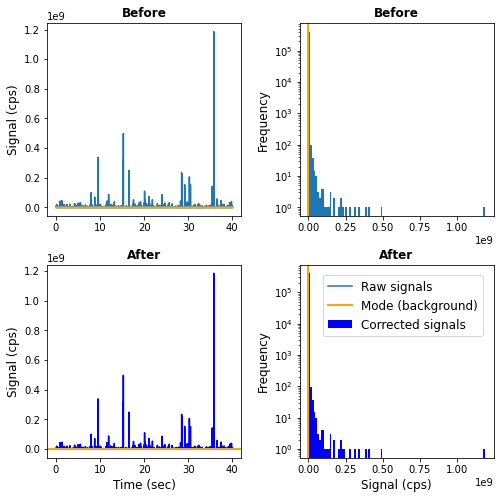

In [48]:
########## Indentifying the baseline ##########
# Static mode
ionic_mode_est = stats.mode(table_OhneZeros[list(table_OhneZeros.columns.values)[1]])
print('Ionic mode estimation: %s' % ionic_mode_est + ' cps')

# Moving mode  (has to be a panda series, but x and y are already, otherwise pd.Series(x) etc.)
y_series = y.rolling(100)

y_moving_modes = []
for _ in y_series:
    y_moving_modes.append(min(_))  #stats.mode(_) for the mode

anchor = np.ones(len(x))*stats.mean(y_moving_modes) # mean of mode values (background)

########## Correcting spectrogram for the baseline ##########
y_corr = y.subtract(pd.Series(y_moving_modes))
y_corr = y_corr.add(pd.Series(anchor))

# Let's see how it looks like
figure, axis = plt.subplots(2,2,figsize=(8,8)) 
figure.subplots_adjust(hspace=0.25, wspace=0.3)
axis[0,0].plot(x, y, label='Raw signals')
axis[0,0].plot(x, np.ones(len(x))*ionic_mode_est, linewidth=2, color='orange')

axis[0,1].hist(y, bins = 100, log=True, label="Raw signals")
axis[0,1].axvline(ionic_mode_est, color='orange', linewidth=2, label='Mode (background)')

axis[1,0].plot(x, y_corr, color='b')
axis[1,0].axhline(ionic_mode_est, color='orange', linewidth=2)

axis[1,1].hist(y_corr, bins = 100, log=True, color='b', label="Corrected signals")
axis[1,1].axvline(ionic_mode_est, color='orange', linewidth=2)

axis[0,0].set_title('Before', fontsize=12, fontweight='semibold')
axis[0,1].set_title('Before', fontsize=12, fontweight='semibold')
axis[1,0].set_title('After', fontsize=12, fontweight='semibold')
axis[1,1].set_title('After', fontsize=12, fontweight='semibold')
axis[1,0].set_xlabel('Time (sec)', fontsize=12)
axis[1,1].set_xlabel('Signal (cps)', fontsize=12)
axis[1,0].set_ylabel('Signal (cps)', fontsize=12)
axis[0,0].set_ylabel('Signal (cps)', fontsize=12)
axis[0,1].set_ylabel('Frequency', fontsize=12)
axis[1,1].set_ylabel('Frequency', fontsize=12)

#plt.annotate('n=%s' %sum(~np.isnan(raw_data_Au['Au_0.1_ms_sizes_MassHunter_Agilent_(nm)_2'])), xy=(-0.425, -5), fontsize=15)
####!!!!!!!Set a legend manually!!!!!!!!!#####
legend_elements = [axis[0,0].get_legend_handles_labels()[0][0],              
                   axis[0,1].get_legend_handles_labels()[0][0],
                   axis[1,1].get_legend_handles_labels()[0][0]]
plt.legend(handles=legend_elements, loc=[0.12,0.63], fontsize=12)
# Save figure
plt.savefig(new_name[0] + "_baseline_correction" + ".png", bbox_inches='tight', dpi=300)

########## Reconverting into a format that the rest of the code can use without any other changes ##########
tuple_d = []
for i in range(len(x)):
    tuple_d.append([x[i],y_corr[i]])
    
new_table_wZeros = pd.DataFrame((tuple_d),columns=['Time [Sec]','Element [cps]'])
new_table_OhneZeros = new_table_wZeros[new_table_wZeros[list(new_table_wZeros.columns.values)[1]] > 0]

table1 = new_table_OhneZeros
table = new_table_wZeros

# Iteration (40 times) or clear cut function to get particle detection thresholds (Gaussian)

In [49]:
#Collecting TableX and iterating to obtain optimal PDT values
#for the mean part
def o_mean_sig_perX(tableX,i):
    mean = np.mean(tableX.iloc[:, 1])
    sd = np.std(tableX.iloc[:, 1])
    value = mean + i*sd
    return value

#for the a part
def a_meanX(tableX,mean_sig_X):
    shortened_tables = tableX[tableX.iloc[:, 1] < mean_sig_X]
    return shortened_tables

################ Fuction to identify a clear cut in the histograms (good for millisecond dwell times) ################
def clear_cut(tableX):
    x = np.histogram(tableX.iloc[:, 1], bins=100)
    i = 0
    for key in x[1][:-1]:
        if x[0][i] == 0:
            cps = key
            break
        i += 1
    return cps

# Then run the iterations for the given SD trials
sd_trials = [3,4,5,6,7]        # This is "X"
tableX_dict = {}
PDT_list = []

guide = clear_cut(table1)

for i in sd_trials:
    tableX = table1
    name = 'PDT{}'.format(i)   # 'PDT{}'.format(value that will be written inside{}) ==> outputs: PDT3, PDT4, etc.
    
    for count in np.arange(0,40): # For 40 iterations
        meanANDsig = o_mean_sig_perX(tableX,i) 
        a_res = a_meanX(tableX,meanANDsig)
        
        if clear_cut_index == True and count == 35 and meanANDsig > guide:
            meanANDsig = guide
            a_res = a_meanX(tableX,guide)
            break
        
        if np.isnan(meanANDsig) == False and len(a_res) == 0:
            meanANDsig = meanANDsig_previous
            a_res = a_meanX(tableX,meanANDsig_previous)
            break

        tableX = a_res
        meanANDsig_previous = meanANDsig
        
    PDT_list.append((name,meanANDsig))
    tableX_dict['tableX{}'.format(i)] = tableX

# print('This is the %s th iteration' %count)
for p in range(len(PDT_list)):
    print('The Particle Detection Threshold (µ + {}SD) is:  '.format(sd_trials[p]), np.around(PDT_list[p][1]))

# Save as variables    
PDT3 = PDT_list[0][1]
PDT4 = PDT_list[1][1]
PDT5 = PDT_list[2][1]
PDT6 = PDT_list[3][1]
PDT7 = PDT_list[4][1]

The Particle Detection Threshold (µ + 3SD) is:   564815.0
The Particle Detection Threshold (µ + 4SD) is:   648337.0
The Particle Detection Threshold (µ + 5SD) is:   732664.0
The Particle Detection Threshold (µ + 6SD) is:   818921.0
The Particle Detection Threshold (µ + 7SD) is:   907549.0


# Calculation of background (average/mode) from the whole dataset below PDT (Gaussian)

In [50]:
###### Calculation of ionic background (average/mode) from the whole dataset < PDT = for Gaussian method
def mean_mode_ionic(tableX_name,i):
    name = 'mean_and_mode_ionic_cps_{}'.format(i)
    res_mean = np.mean(tableX_name[tableX_name.keys()[1]])    # Call the values inside the dictionary for the key "element" and not the "time"
    res_mode = stats.mode(tableX_name[tableX_name.keys()[1]]) # tableX_name[tableX_name] includes all values below PDT (background)
    return name,res_mean,res_mode     

mean_mode_ionic_cps_list = []

for i in sd_trials:
    tableX_i = tableX_dict['tableX{}'.format(i)]    # Table with values below PDT (all); tableX (with "zeros")   
    mean_mode_ionic_res = mean_mode_ionic(tableX_i,i)
    mean_mode_ionic_cps_list.append(mean_mode_ionic_res)

# To call the values inside the dictionary = tableY_dict['tableY5']['Au197'])) -> for original dict
# To identify which key it is in = tableY_dict['tableY5'].keys()[1] -> for original dict
# for the new dictionaries = table_minus_bckg['tableY3']

#mean_mode_ionic_cps_list["0=µ+3SD;1=µ+4SD; ...; 4=µ+7SD"][0=name;1=mean;2=mode]  ;  e.g. for mode µ + 3SD --> mean_mode_ionic_cps_list[0][2]

# Particle detection threshold and critical value (Poisson)

In [51]:
##### Critical value (LC) is limit from where a signal will be cosidered as particle if also above PDT
##### PDT_poisson is the detection limit when a particle will be considered as particle
###ATTENTION: poisson calculations are defined only for the MEAN!! adapt for MODE if required

def Poisson_method(i):
    name = 'Poisson_LC_and_PDT_{}'.format(i)
    p = i-sd_trials[0]
    LC_poisson = np.mean(table[list(table.columns.values)[1]]) + (2.33 * (np.mean(table[list(table.columns.values)[1]]) * dwell + e)**(1/2)) / dwell # Takes the whole average of all data

    PDT_poisson = np.mean(table[list(table.columns.values)[1]]) + 2.71 + 4.65 * ((np.mean(table[list(table.columns.values)[1]]) * dwell + e)**(1/2)) / dwell # Takes the whole average of all data

    return name,LC_poisson,PDT_poisson
poisson_limits = []
for i in sd_trials[0:1]:
    p = i-sd_trials[0]
    if np.mean(table[list(table.columns.values)[1]]) < 5/dwell:    
        e = 0.5         ##### For low background correction term 0.5 otherwise 0
    else:
        e = 0
    poisson_limits.append(Poisson_method(i))
    print('Critical value (LC) (Poisson) [CPS] = %s'.format(i) % poisson_limits[i-3][1])
    print('Particle detection threshold (Poisson) [CPS] = %s'.format(i) % poisson_limits[i-3][2])

Critical value (LC) (Poisson) [CPS] = 549396.9403911638
Particle detection threshold (Poisson) [CPS] = 696444.2033787442


# Calculation of background (average/mode) from the whole dataset below PDT (Poisson)

In [52]:
###### Calculation of ionic background (average/mode) from the whole dataset < PDT = for Poisson method
mean_mode_ionic_cps_list_poisson = []

for i in sd_trials[0:1]:
    tableX_i = table1[table1.iloc[:, 1] < poisson_limits[i-3][2]]
    mean_mode_ionic_cps_list_poisson.append(mean_mode_ionic(tableX_i,i))

# Plot all data and show PDT to choose the best PDT (Gaussian)

In [53]:
# ----- Zoom functions -----
def connect_bbox(bbox1, bbox2, loc1a, loc2a, loc1b, loc2b, prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = prop_lines.copy()
        prop_patches["alpha"] = prop_patches.get("alpha", 1)*0.2
    c1 = BboxConnector(bbox1, bbox2, alpha=0.5, loc1=loc1a, loc2=loc2a, **prop_lines)
    c1.set_clip_on(False)
    c2 = BboxConnector(bbox1, bbox2, alpha=0.5, loc1=loc1b, loc2=loc2b, **prop_lines)
    c2.set_clip_on(False)
    bbox_patch1 = BboxPatch(bbox1, **prop_patches)
    bbox_patch2 = BboxPatch(bbox2, **prop_patches)
    p = BboxConnectorPatch(bbox1, bbox2,
                           loc1a=loc1a, loc2a=loc2a, loc1b=loc1b, loc2b=loc2b,
                           **prop_patches)
    p.set_clip_on(False)
    return c1, c2, bbox_patch1, bbox_patch2, p

def zoom_effect02(ax1, ax2, **kwargs):
    tt = ax1.transScale + (ax1.transLimits + ax2.transAxes)
    trans = blended_transform_factory(ax2.transData, tt)
    mybbox1 = ax1.bbox
    mybbox2 = TransformedBbox(ax1.viewLim, trans)
    prop_patches = kwargs.copy()
    prop_patches["ec"] = "none"
    prop_patches["alpha"] = 0.2
    c1, c2, bbox_patch1, bbox_patch2, p = \
        connect_bbox(mybbox1, mybbox2,
                     loc1a=2, loc2a=3, loc1b=1, loc2b=4, 
                     prop_lines=kwargs, prop_patches=prop_patches)
    ax1.add_patch(bbox_patch1)
    ax2.add_patch(bbox_patch2)
    ax2.add_patch(c1)
    ax2.add_patch(c2)
    ax2.add_patch(p)
    return c1, c2, bbox_patch1, bbox_patch2, p

# ----- Plot setup -----
fig, ax = plt.subplots(figsize=(22,8))
rows = 3
columns = 5
grid = plt.GridSpec(rows, columns, wspace=0.45, hspace=0.35)
color_list = ['green', 'purple', 'k', 'blue', 'orange']
zoom_axes = []

# Keep lists for static elements
full_axes = []
hist_axes = []

# ----- Subplots -----
for p in sd_trials:
    q = p - sd_trials[0]

    # Full-scale plot (draw once)
    ax_ = plt.subplot(grid[q])
    ax_.plot(table1.iloc[:,0], table1.iloc[:,1], color=color_list[q])
    ax_.set_title(f'µ+{p}SD', fontweight='semibold', alpha=0.75)
    ax_.axhline(y=PDT_list[q][1], color='red')
    full_axes.append(ax_)

    # Zoom plot (animated)
    ax__ = plt.subplot(grid[q+5])
    zoom_effect02(ax__, ax_)
    ax__.plot(table1.iloc[:,0], table1.iloc[:,1], color=color_list[q])
    ax__.set_yscale('log')
    ax__.axhline(y=PDT_list[q][1], color='red')
    ax__.set_ylim(round_sig(int(PDT_list[q][1]))/5,
                  round_sig(int(PDT_list[q][1]))*5)
    zoom_axes.append(ax__)

    # Histogram (draw once)
    ax___ = plt.subplot(grid[q+10])
    ax___.hist(table1.iloc[:,1], bins=200, alpha=1, color=color_list[q])
    ax___.set_yscale('log')
    ax___.axvline(x=PDT_list[q][1], color='red')
    hist_axes.append(ax___)

# ----- Animation setup -----
x_min, x_max = table1.iloc[:,0].min(), table1.iloc[:,0].max()
window_size = 1.0  # 1-second zoom window
n_frames = 25      # number of frames
interval_ms = 1000 # 1 second per frame

def update(frame):
    start = x_min + (x_max - x_min - window_size) * frame / (n_frames - 1)
    end = start + window_size
    for ax in zoom_axes:
        ax.set_xlim(start, end)
    return zoom_axes

ani = FuncAnimation(fig, update, frames=n_frames, interval=interval_ms, blit=False)

# ----- Save as GIF -----
ani.save(new_name[0] + "_time_zoom_gaussian.gif", dpi=300, writer=PillowWriter(fps=1))

# ----- Prevent static figure from showing in Jupyter -----
plt.close(fig)

# ----- Display animation only -----
HTML(ani.to_jshtml())

# Calculation of background (average/mode) from the whole dataset below PDT (Gaussian)

In [54]:
###### Calculation of ionic background (average/mode) from the whole dataset < PDT = for Gaussian method
def mean_mode_ionic(tableX_name,i):
    name = 'mean_and_mode_ionic_cps_{}'.format(i)
    res_mean = np.mean(tableX_name[tableX_name.keys()[1]])    # Call the values inside the dictionary for the key "element" and not the "time"
    res_mode = stats.mode(tableX_name[tableX_name.keys()[1]]) # tableX_name[tableX_name] includes all values below PDT (background)
    return name,res_mean,res_mode     

mean_mode_ionic_cps_list = []

for i in sd_trials:
    tableX_i = tableX_dict['tableX{}'.format(i)]    # Table with values below PDT (all); tableX (with "zeros")   
    mean_mode_ionic_res = mean_mode_ionic(tableX_i,i)
    mean_mode_ionic_cps_list.append(mean_mode_ionic_res)

# To call the values inside the dictionary = tableY_dict['tableY5']['Au197'])) -> for original dict
# To identify which key it is in = tableY_dict['tableY5'].keys()[1] -> for original dict
# for the new dictionaries = table_minus_bckg['tableY3']

#mean_mode_ionic_cps_list["0=µ+3SD;1=µ+4SD; ...; 4=µ+7SD"][0=name;1=mean;2=mode]  ;  e.g. for mode µ + 3SD --> mean_mode_ionic_cps_list[0][2]

# Plot all data and show PDT to choose the best PDT (Poisson)

In [55]:
# ----- Plot setup -----
fig, ax = plt.subplots(figsize=(6,8))
rows = 3
columns = 1
grid = plt.GridSpec(rows, columns, wspace=0.4, hspace=0.35)

# Full-scale plot
ax1 = plt.subplot(grid[0])
ax1.plot(table1.iloc[:,0], table1.iloc[:,1], color='gray')
ax1.set_title('Poisson', fontweight='semibold', alpha=0.75)
ax1.set_xlabel('Time / s', fontsize=12, fontweight='semibold')
ax1.set_ylabel('Signal / cps', fontsize=12, fontweight='semibold')
ax1.grid(alpha=0.05)
ax1.tick_params(labelsize=12)
ax1.axhline(y=poisson_limits[0][1], color='green', ls='--')  # Lc
ax1.axhline(y=poisson_limits[0][2], color='red')  # Ld

# Zoom plot (animated)
ax2 = plt.subplot(grid[1])
zoom_effect02(ax2, ax1)
ax2.plot(table1.iloc[:,0], table1.iloc[:,1], color='gray')
ax2.set_yscale('log')
ax2.set_xlabel('Time / s', fontsize=12, fontweight='semibold')
ax2.set_ylabel('Signal / cps', fontsize=12, fontweight='semibold')
ax2.grid(alpha=0.05)
ax2.tick_params(labelsize=12)
ax2.axhline(y=poisson_limits[0][1], color='green', ls='--')
ax2.axhline(y=poisson_limits[0][2], color='red')
ax2.set_ylim(round_sig(int(poisson_limits[0][2]))/5,
             round_sig(int(poisson_limits[0][1]))*5)

# Histogram
ax3 = plt.subplot(grid[2])
ax3.hist(table1.iloc[:,1], bins=500, alpha=1, color='gray', label='Histogram PDT (Poisson)')
ax3.set_yscale('log')
ax3.set_xlabel('Signal / cps', fontsize=12, fontweight='semibold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='semibold')
ax3.grid(alpha=0.05)
ax3.tick_params(labelsize=12)
ax3.axvline(x=poisson_limits[0][1], color='green', ls='--')
ax3.axvline(x=poisson_limits[0][2], color='red')

# ----- Animation setup -----
x_min, x_max = table1.iloc[:,0].min(), table1.iloc[:,0].max()
window_size = 1.0  # 1-second zoom window
n_frames = 25      # number of frames
interval_ms = 1000 # 1 second per frame

def update(frame):
    start = x_min + (x_max - x_min - window_size) * frame / (n_frames - 1)
    end = start + window_size
    ax2.set_xlim(start, end)
    return [ax2]

ani = FuncAnimation(fig, update, frames=n_frames, interval=interval_ms, blit=False)

# ----- Save as GIF -----
ani.save(new_name[0] + "_time_zoom_poisson.gif", dpi=300, writer=PillowWriter(fps=1))

# ----- Prevent static figure from showing -----
plt.close(fig)

# ----- Display animation only -----
HTML(ani.to_jshtml())

# Peak integration (Gaussian)

In [56]:
### Peak integration based on two approaches and PDT as background levels #### [with zeros]

tableY_cps = list(table.iloc[:,1])
All_peak_sums = []
All_ionic_signal_list = [] # values (ionic signal - ionic mean values) for the plot
corr_background = [] # This is needed as we substract the background mean from every signal --> Therefore we also need to substract the background mean from each PDT for the plot!!!

for i in sd_trials:
    background = round(PDT_list[i-3][1],1)  # PDT from Gaussian approach (iterations)
    peak_sums_list = []
    ionic_signal_list = []
    real_position_o = 0
    peak_events_o = 0
    delta_o = 0
    peak = 0
    corr_background.append(background - mean_mode_ionic_cps_list[i-3][1]) # "New" PDT's for the plots!
    
    while real_position_o < len(tableY_cps)-1:
#         print("position = " + str(real_position_o) + " value of raw cps = " + str(round(tableY_cps[real_position_o],0)))
        delta_o = 0
        
        if tableY_cps[real_position_o] >= background:
            peak_events_o += 1
            peak = 0    
            
            if tableY_cps[real_position_o+1] < background:
                peak = tableY_cps[real_position_o] - mean_mode_ionic_cps_list[i-3][1]   # This goes to the peak not to the background
                #print("position = " + str(real_position_o), tableY_cps[real_position_o], peak)

                if peak < 0.0:
                    print("too high ionic background correction -> negative cps to the peak contribution") 
                
            else: 
                if dwell >= 0.002:
                    peak = tableY_cps[real_position_o] - mean_mode_ionic_cps_list[i-3][1]
                    
                else:
                    while tableY_cps[real_position_o+delta_o] >= background and delta_o < 1000:
                        peak += tableY_cps[real_position_o+delta_o] - mean_mode_ionic_cps_list[i-3][1]
                        delta_o += 1

                        if delta_o == 999:
                            print("need more range in scoping")
                            break     
                            
                        if real_position_o+delta_o >= len(tableY_cps):
                            print("reached the end of the dataset")
                            break  
                    delta_o = delta_o - 1
                    
            peak_sums_list.append(int(peak))
        
        else:
            if tableY_cps[real_position_o] != 0.0:
                ionic_signal_list.append(tableY_cps[real_position_o]) # here is where you have the background cps without removal of mean ionic signal
        
        real_position_o += 1 + delta_o       
    
    All_peak_sums.append(peak_sums_list)
    All_ionic_signal_list.append(ionic_signal_list) # Ionic background
    
#TAKE DATA FROM
#All_peak_sums --> Take particle Data from here
#All_ionic_signal_list --> Take background/ionic data from here

# Peak integration (Poisson)

In [57]:
### Peak integration based on two approaches and PDT as background levels #### [with zeros]

#tableY_time = list(table.iloc[:,0])
tableY_cps = list(table.iloc[:,1])

All_peak_sums_poisson = []
All_ionic_signal_list_poisson = []  # real values without substraction (ionic signal - ionic mean values)
corr_background_poisson = []

for i in sd_trials[0:1]:
    background_LD = round(poisson_limits[i-3][2],1)   # Particle detection threshold
    background_LC = round(poisson_limits[i-3][1],1)   # Critical value
    peak_sums_list_poisson = []
    ionic_signal_list_poisson = []
    real_position_o_poisson = 0
    peak_events_o_poisson = 0
    corr_background_poisson.append(background_LD - mean_mode_ionic_cps_list_poisson[i-3][1]) # Background (all data) minus mean (data below original PDT) --> Corrected poisson limits (PDT's)
    
    # First checks if cps are above LC. Then checks if the next cps are also above the LD. Only then, we account for particle event. If not, all is ionic.
    #print("LC = " + str(background_LC) + " and LD = " + str(background_LD))
    
    while real_position_o_poisson < len(tableY_cps)-1:        
        #print("position = " + str(real_position_o_poisson) + ", value = " + str(tableY_cps[real_position_o_poisson]))
        delta_o = 0
        peak_poisson = 0
        
        if tableY_cps[real_position_o_poisson] >= background_LC:                
                
            if tableY_cps[real_position_o_poisson] >= background_LD:
#                print("position = " + str(real_position_o_poisson) + ", value = " + str(tableY_cps[real_position_o_poisson]) + " > " + str(background_LD))
                peak_events_o_poisson += 1
                     
                if dwell >= 0.002:
                    peak_poisson = tableY_cps[real_position_o_poisson] - mean_mode_ionic_cps_list_poisson[i-3][1]
                    #for 5ms we don't account for peaks between LC and LD
                
                else:
                    standing_peak = tableY_cps[real_position_o_poisson] - mean_mode_ionic_cps_list_poisson[i-3][1]
                    #print("values in play = " + str(tableY_cps[real_position_o_poisson-2]) + ", " + str(tableY_cps[real_position_o_poisson-1]) + " < " + str(tableY_cps[real_position_o_poisson]) + " > " + str(tableY_cps[real_position_o_poisson+1]) + ", " + str(tableY_cps[real_position_o_poisson+2]))
                    
                    if tableY_cps[real_position_o_poisson-1] >= background_LC:
                        delta_i = 1
                        while tableY_cps[real_position_o_poisson-delta_i] >= background_LC and delta_i < 1000:
                            standing_peak += tableY_cps[real_position_o_poisson-delta_i] - mean_mode_ionic_cps_list_poisson[i-3][1]
                            delta_i +=1
                            
                            if delta_i == 999:
                                print("need more range in backwards scoping")
                                break 
                                
                        #print("pre-preak added = " + str(standing_peak))
                        
                    if tableY_cps[real_position_o_poisson+1] < background_LC:
                        peak_poisson = standing_peak 
                        #print("end of standing peak") 

                    else:    
                        delta_o = 1
                        
                        while tableY_cps[real_position_o_poisson+delta_o] >= background_LC and delta_o < 1000:
                            standing_peak += tableY_cps[real_position_o_poisson+delta_o] - mean_mode_ionic_cps_list_poisson[i-3][1]
                            #print("delta = " + str(delta_o) + ", value = " + str(standing_peak))
                            delta_o += 1
                            
                            if delta_o == 999:
                                print("need more range in scoping")
                                break           
                        peak_poisson = standing_peak 
                        delta_o = delta_o - 1
                        
                peak_sums_list_poisson.append(int(peak_poisson))
                #print(peak_sums_list_poisson)
        else:
            if tableY_cps[real_position_o_poisson] != 0.0:            
                ionic_signal_list_poisson.append(tableY_cps[real_position_o_poisson])   #Calculation of ionic background

        real_position_o_poisson += 1 + delta_o 
        

    All_peak_sums_poisson.append(peak_sums_list_poisson)
    All_ionic_signal_list_poisson.append(ionic_signal_list_poisson) # Calculation of ionic background

#TAKE DATA FROM
#All_peak_sums_poisson --> Take particle Data from here
#All_ionic_signal_list_poisson --> Take background/ionic data from here

# Convert data from list into pandas dataframe & calculate ionic concentration (Gaussian)

In [58]:
### Ionic data from here
def dataframe_particle_ionic_mode(i):
    name = 'particle_ionic_mode_{}'.format(i)
    p = i-sd_trials[0]
    
# Check if the dataset is empty, if true print text and proceed
    if not All_ionic_signal_list[p] or not All_peak_sums[p]:
        print('No data below Gaussian µ+{}SD PDT.'.format(i))
        return name, None, None, None
    
    dataframe_sums = pd.DataFrame(All_peak_sums[p])
    dataframe_ionic = pd.DataFrame(All_ionic_signal_list[p])
    ionic_mode = (stats.mode(dataframe_ionic[0])-intercept) / response
    return name,dataframe_sums,dataframe_ionic,ionic_mode

dataframe_particle_ionic_mode_list = []

for i in sd_trials:
    dataframe_particle_ionic_mode_list.append(dataframe_particle_ionic_mode(i))

for p in range(len(dataframe_particle_ionic_mode_list)):
    ionic_mode = dataframe_particle_ionic_mode_list[p][3]
    if ionic_mode is not None:
        print('The ionic conc. (Gaussian µ + {}SD) [µg/L] is = '.format(sd_trials[p]), ionic_mode)

# Take ionic data from: dataframe_particle_ionic_mode_list_plot[0][2]

The ionic conc. (Gaussian µ + 3SD) [µg/L] is =  3.9030044884178636
The ionic conc. (Gaussian µ + 4SD) [µg/L] is =  3.9030044884178636
The ionic conc. (Gaussian µ + 5SD) [µg/L] is =  3.9030044884178636
The ionic conc. (Gaussian µ + 6SD) [µg/L] is =  3.9030044884178636
The ionic conc. (Gaussian µ + 7SD) [µg/L] is =  3.9030044884178636


# Convert data from list into pandas dataframe & calculate ionic concentration (Poisson)

In [59]:
### Just for the plot to get the ionic data minus mean (background) which are lower than the corrected PDT
def dataframe_particle_ionic_mode_poisson(i):
    name = 'particle_ionic_mode_{}'.format(i)
    p = i-sd_trials[0]
    
# Check if the dataset is empty, if true print text and proceed
    if not All_ionic_signal_list_poisson[p] or not All_peak_sums_poisson[p]:
        print('No data below Poisson PDT.'.format(i))
        return name, None, None, None
    
    dataframe_sums = pd.DataFrame(All_peak_sums_poisson[p])
    dataframe_ionic = pd.DataFrame(All_ionic_signal_list_poisson[p])
    ionic_mode = (stats.mode(dataframe_ionic[0])-intercept) / response
    return name,dataframe_sums,dataframe_ionic,ionic_mode

dataframe_particle_ionic_mode_list_poisson = []

for i in sd_trials[0:1]:
    dataframe_particle_ionic_mode_list_poisson.append(dataframe_particle_ionic_mode_poisson(i))

for p in range(1):
    ionic_mode = dataframe_particle_ionic_mode_list_poisson[p][3]
    if ionic_mode is not None:
        print('The ionic conc. (Poisson) [µg/L] is = '.format(sd_trials[p]), ionic_mode)

# Take ionic data for plotting from: dataframe_particle_ionic_mode_list_poisson_plot[p][2]

The ionic conc. (Poisson) [µg/L] is =  3.9030044884178636


## Remove outliers [>µ+i * SD from all particles] (high signals e.g. agglomerates) (Gaussian)

###  !!! If needed: adapt factor i * SD !!!

In [60]:
def outlier_discrimination(i,used_table):
    name = 'outlier_discrimination_{}'.format(i)
    mean_particles = np.mean(used_table[0])
    sd_particles = np.std(used_table[0])
    meansig_outliers = mean_particles + 3 * sd_particles
    if outlier_removal == True:
        outliers_table = used_table[used_table[0] > meansig_outliers]
        particles_table = used_table[used_table[0] <= meansig_outliers]     
    else:
        outliers_table = used_table[used_table[0] > 1.0e20]
        particles_table = used_table[used_table[0]<= 1.0e20]
    return name, outliers_table, particles_table

outliers_particles_data = []

for i in sd_trials:
    p = i - sd_trials[0]
# Skip and continue if datasets are empty  
    table = dataframe_particle_ionic_mode_list[p][1]
    if table is None:
        print('No data for Gaussian µ+{i}SD available.')
        continue
    used_table = table.iloc[:, :]
    outliers_particles_data.append(outlier_discrimination(i,used_table))
    
#outlier values are in => outliers_particles_data_poisson[p][1]
#particle values are in => outliers_particles_data_poisson[p][2]

## Remove outliers [>µ+i * SD from all particles] (high signals e.g. agglomerates) (Poisson)

###  !!! If needed: adapt factor i * SD !!!

In [61]:
def outlier_discrimination_poisson(i,used_table_poisson):
    name = 'outlier_discrimination_{}'.format(i)
    mean_particles = np.mean(used_table_poisson[0])
    sd_particles = np.std(used_table_poisson[0])
    meansig_outliers = mean_particles + 3 * sd_particles # before, the 3 was an "i" But here it should be 3 by default!!!!
    if outlier_removal == True:
        outliers_table = used_table_poisson[used_table_poisson[0] > meansig_outliers]
        particles_table = used_table_poisson[used_table_poisson[0] <= meansig_outliers]
    else:
        outliers_table = used_table_poisson[used_table_poisson[0] > 1.0e20]
        particles_table = used_table_poisson[used_table_poisson[0]<= 1.0e20]
    return name, outliers_table, particles_table

outliers_particles_data_poisson = []

for i in sd_trials[0:1]:
    p = i - sd_trials[0]
# Skip and continue if datasets are empty  
    table = dataframe_particle_ionic_mode_list_poisson[p][1]
    if table is None:
        print('No data for Poisson available.')
        continue
    used_table_poisson = table.iloc[:, :]
    All_in_one_poisson = outlier_discrimination_poisson(i,used_table_poisson)
    outliers_particles_data_poisson.append(All_in_one_poisson)
    
#outlier values are in => outliers_particles_data_poisson[p][1]
#particle values are in => outliers_particles_data_poisson[p][2]

## Number of events (Gaussian)

In [62]:
def PNC_calculator(i,valid_events,outlier_events):
    name = 'event_number_{}'.format(i)
    no_conc = (valid_events/(total_aquisition_time * te * flow)) * DF # Final conc. including DF
    no_conc_exp = '%.2E' % Decimal(no_conc)
    return name,valid_events,no_conc_exp,outlier_events,no_conc

event_number_list = []

for i in sd_trials:
    p = i-sd_trials[0]
# Skip and continue if datasets are empty  
    if p >= len(outliers_particles_data) or outliers_particles_data[p] is None:
        print(f"No particle data for Gaussian µ+{i}SD available.")
        continue
    valid_events = len(outliers_particles_data[p][2])
    outlier_events = len(outliers_particles_data[p][1])
    event_number_list.append(PNC_calculator(i,valid_events,outlier_events))
    
for p in range(len(event_number_list)):
    print('Particle conc (µ + {} SD) [particles/mL] = '.format(sd_trials[p]), event_number_list[p][2])

##Valid particle events values are in => event_number_list[p][1]
##Valid no_conc values are in => event_number_list[p][2]
##Outlier events values are in => event_number_list[p][3]
##Valid no_conc values to calculate are in => event_number_list[p][4]

Particle conc (µ + 3 SD) [particles/mL] =  1.35E+14
Particle conc (µ + 4 SD) [particles/mL] =  8.18E+13
Particle conc (µ + 5 SD) [particles/mL] =  6.40E+13
Particle conc (µ + 6 SD) [particles/mL] =  5.34E+13
Particle conc (µ + 7 SD) [particles/mL] =  4.64E+13


## Number of events (Poisson)

In [63]:
event_number_list_poisson = []

for i in sd_trials[0:1]:
    p = i-sd_trials[0]
# Skip and continue if datasets are empty  
    if p >= len(outliers_particles_data_poisson) or outliers_particles_data_poisson[p] is None:  # NEW: skip if missing
        print(f"No particle data for Poisson available.")  # NEW
        continue
    valid_events = len(outliers_particles_data_poisson[p][2])
    outlier_events = len(outliers_particles_data_poisson[p][1])
    event_number_list_poisson.append(PNC_calculator(i,valid_events,outlier_events))

for p in range(len(event_number_list_poisson)):
    print('Particle conc. (Gaussian µ + {} SD) [particles/mL] = '.format(sd_trials[p]), event_number_list_poisson[p][2])

##Valid particle events values are in => event_number_list_poisson[p][1]
##Valid no_conc values are in => event_number_list_poisson[p][2]
##Outlier events values are in => event_number_list_poisson[p][3]

Particle conc. (Gaussian µ + 3 SD) [particles/mL] =  7.15E+13


## Histograms (Gaussian)

<ipython-input-64-e11fe8f289f0>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax_ = plt.subplot(grid[q])
<ipython-input-64-e11fe8f289f0>:44: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax__ = plt.subplot(grid[q+5]) # Zoom µ + SD


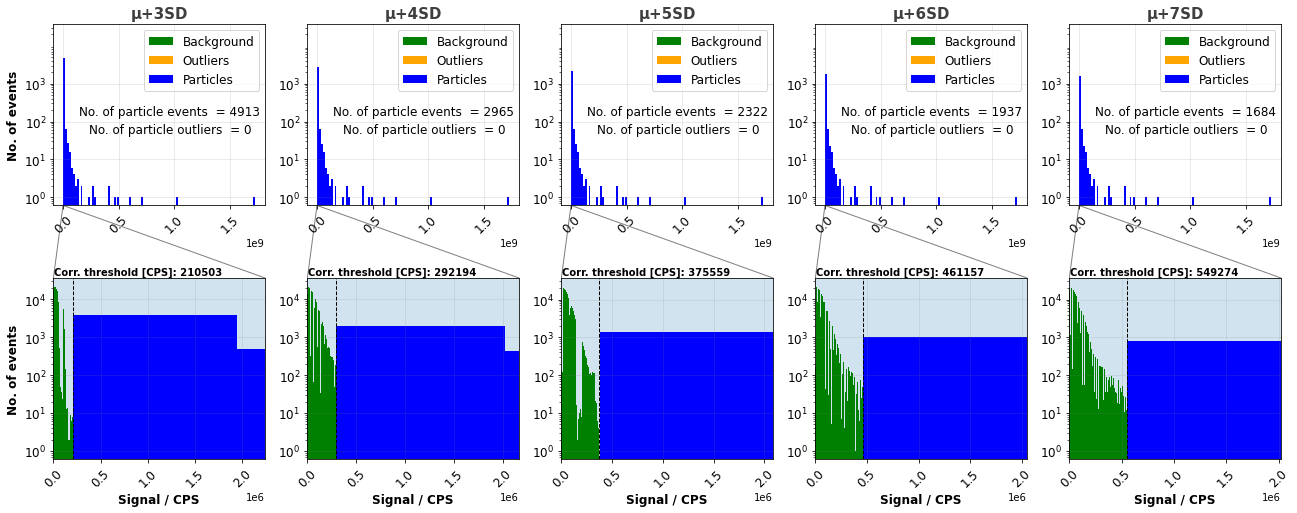

In [64]:
# Plot function
fig, ax = plt.subplots(figsize=(22,8))
rows = 2
columns = 5

#Is needed that you can have more than 9 subplots
grid = plt.GridSpec(rows, columns, wspace = .20, hspace = .4)
for i in range(rows*columns):
    exec (f"plt.subplot(grid{[i]})")
    plt.annotate('subplot 35_grid[' + str(i) + ']', xy = (0.5, 0.5), va = 'center', ha = 'center')

for p in sd_trials:
    q = p-sd_trials[0]    
# Skip and continue if datasets are empty    
    if (q >= len(dataframe_particle_ionic_mode_list) or 
        q >= len(outliers_particles_data)):
        print(f"No data for Gaussian µ+{p}SD.")
        continue
    if (dataframe_particle_ionic_mode_list[q][2] is None or 
        outliers_particles_data[q] is None):
        print(f"No data for Gaussian µ+{p}SD.")
        continue

    #Subplot definitions    
    ax_ = f'ax{q+1}'
    ax_ = plt.subplot(grid[q])

    plt.hist((dataframe_particle_ionic_mode_list[q][2]-np.mean(All_ionic_signal_list[q])), bins=99, alpha=1, color='green', label='Background')
    plt.hist(outliers_particles_data[q][1], color='orange',bins=99, alpha=1, label='Outliers')
    plt.hist(outliers_particles_data[q][2], bins=99, color='blue', alpha=1, label='Particles')
    plt.yscale('log')
    plt.annotate('No. of particle events  = %s' %event_number_list[q][1], xy=(0.12, 0.5), xycoords='axes fraction', fontsize=12)
    plt.annotate('No. of particle outliers  = %s' %event_number_list[q][3], xy=(0.17, 0.4), xycoords='axes fraction', fontsize=12)
    plt.title(f'µ+{p}SD', fontsize=15, fontweight='semibold', alpha=0.75)
    if q == 0:
        plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    plt.xscale('linear')
    plt.legend(loc=1, prop={'size':12})
    plt.grid(color= 'gray', alpha=0.2)
    plt.xticks(rotation = 45, fontsize=12)
    plt.yticks([1,10,100,1000],fontsize=12)
    
    ax__ = f'ax{q+6}'
    ax__ = plt.subplot(grid[q+5]) # Zoom µ + SD
    
    zoom_effect02(ax__, ax_)
    plt.hist((dataframe_particle_ionic_mode_list[q][2]-np.mean(All_ionic_signal_list[q])), bins=99, alpha=1, color='green', label='Background')
    plt.hist(outliers_particles_data[q][1], color='orange',bins=99, alpha=1, label='Outliers')
    plt.hist(outliers_particles_data[q][2], bins=999, color='blue', alpha=1, label='Particles')
    plt.xlabel('Signal / CPS', fontsize=12, fontweight='semibold')
    if q == 0:
        plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    plt.yscale('log')
    plt.xscale('linear')
    plt.xlim(int(0), (round_sig(int(PDT_list[q][1])))*20/(q+1*5)) # Zoom on x axis
    plt.grid(color= 'gray', alpha=0.2)
    plt.xticks(rotation = 45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.axvline(corr_background[q], color='black', lw=1, ls='--')
    plt.annotate('Corr. threshold [CPS]: %s' %int(corr_background[q]), xy=(0.004, 1.02), xycoords='axes fraction', fontsize=10, fontweight= 'semibold')

# Save figure
plt.savefig(new_name[0] + "_sums_zoom_gaussian" + ".png", bbox_inches='tight', dpi=300)

## Histograms (Poisson)

<ipython-input-65-dcaee4358e05>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax1 = plt.subplot(grid[0])
<ipython-input-65-dcaee4358e05>:42: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  ax2 = plt.subplot(grid[1])


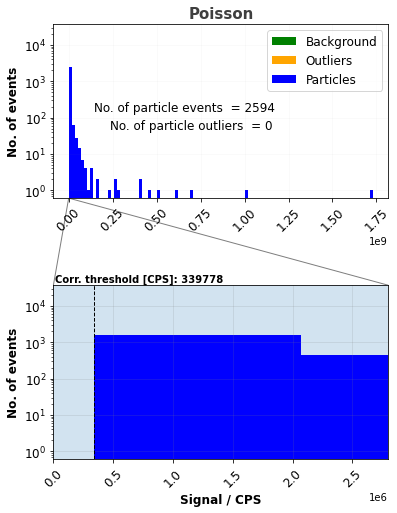

In [65]:
# Plot function
fig, ax = plt.subplots(figsize=(6,8))
rows = 2
columns = 1

# Check once before doing any plotting
if (len(dataframe_particle_ionic_mode_list_poisson) == 0 or 
    dataframe_particle_ionic_mode_list_poisson[0][2] is None or
    len(outliers_particles_data_poisson) == 0 or
    outliers_particles_data_poisson[0] is None):
    print("No data for Poisson.")
else:
    #Is needed that you can have more than 9 subplots
    grid = plt.GridSpec(rows, columns, wspace = .20, hspace = .5)
    for i in range(rows*columns):
        exec (f"plt.subplot(grid{[i]})")
    # Skip and continue if datasets are empty    
        if (i >= len(dataframe_particle_ionic_mode_list_poisson) or 
            i >= len(outliers_particles_data_poisson)):
            continue
        if (dataframe_particle_ionic_mode_list_poisson[i][2] is None or 
            outliers_particles_data_poisson[i] is None):
            continue

    # Full Scale (Poisson)
    ax1 = plt.subplot(grid[0])
    plt.hist((dataframe_particle_ionic_mode_list_poisson[0][2]-poisson_limits[0][1]), bins=99, alpha=1, color='green', label='Background')
    plt.hist(outliers_particles_data_poisson[0][1], color='orange',bins=100, alpha=1, label='Outliers')
    plt.hist(outliers_particles_data_poisson[0][2], bins=100, color='blue', alpha=1, label='Particles')
    plt.annotate('No. of particle events  = %s' %event_number_list_poisson[0][1], xy=(0.12, 0.5), xycoords='axes fraction', fontsize=12)
    plt.annotate('No. of particle outliers  = %s' %event_number_list_poisson[0][3], xy=(0.17, 0.4), xycoords='axes fraction', fontsize=12)
    plt.title('Poisson', fontsize=15, fontweight='semibold', alpha=0.75)
    plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    plt.yscale('log')
    plt.xscale('linear')
    plt.legend(loc=1, prop={'size':12})
    plt.grid(color= 'gray', alpha=0.05)
    plt.xticks(rotation = 45, fontsize=12)
    plt.yticks(fontsize=12)

    # Zoom (Poisson)
    ax2 = plt.subplot(grid[1]) 
    zoom_effect02(ax2, ax1)
    plt.hist((dataframe_particle_ionic_mode_list_poisson[0][2]-poisson_limits[0][1]), bins=99, alpha=1, color='green', label='Background')
    plt.hist(outliers_particles_data_poisson[0][1], color='orange',bins=99, alpha=1, label='Outliers')
    plt.hist(outliers_particles_data_poisson[0][2], bins=999, color='blue', alpha=1, label='Particles')
    plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    plt.yscale('log')
    plt.xscale('linear')
    plt.xlim(int(0), (round_sig(int(poisson_limits[0][2])))*20/(1*5)) # Zoom on x axis
    plt.grid(color= 'gray', alpha=0.2)
    plt.xticks(rotation = 45, fontsize=12)
    plt.yticks(fontsize=12)
    plt.axvline(corr_background_poisson[0], color='black', lw=1, ls='--')
    plt.annotate('Corr. threshold [CPS]: %s' %int(corr_background_poisson[0]), xy=(0.004, 1.02), xycoords='axes fraction', fontsize=10, fontweight= 'semibold',)    
    plt.xlabel('Signal / CPS', fontsize=12, fontweight='semibold')

# Save figure
plt.savefig(new_name[0] + "_sums_zoom_poisson" + ".png", bbox_inches='tight', dpi=300)

## Mass calculation and standard deviations (Gaussian)

In [66]:
def masses(i):
    name = 'particle_mass_{}'.format(i)
    p = i-sd_trials[0]
# Skip empty datasets and print
    if p >= len(outliers_particles_data) or p >= len(dataframe_particle_ionic_mode_list):
        print(f"No masses for µ+{i}SD.")
        return None
    if outliers_particles_data[p] is None or outliers_particles_data[p][2] is None:
        print(f"No masses for µ+{i}SD.")
        return None
    if dataframe_particle_ionic_mode_list[p] is None or dataframe_particle_ionic_mode_list[p][1] is None:
        print(f"No masses for µ+{i}SD.")
        return None
    mass_1 = (((outliers_particles_data[p][2])-intercept)*dwell*flow*te*1000000)/response # in femtogram (fg)
    used_table = dataframe_particle_ionic_mode_list[p][1].iloc[:,:]
    mass = ((used_table-intercept)*dwell*flow*te*1000000)/response # in femtogram (fg)
    
    mean_mass = np.mean(mass)
    median_mass = np.median(mass)
    mode_mass = stats.mode(mass[0])
    sd = np.std(mass)
    return name,mass,mean_mass,median_mass,mode_mass,sd

masses_list = []

for i in sd_trials:
    result = masses(i)
    if result is not None:
        masses_list.append(result)
    
##Particle masses => masses_list[p][1]
##Mean mass => masses_list[p][2]
##Median mass => masses_list[p][3]
##Mode mass => masses_list[p][4]
##Sd mass => masses_list[p][5]''

## Mass calculation and standard deviations (Poisson)

In [67]:
def masses_poisson(i):
    name = 'particle_mass_poisson{}'.format(i)
    p = i - sd_trials[0]

    # Skip empty datasets and print
    if p >= len(outliers_particles_data_poisson) or \
       outliers_particles_data_poisson[p] is None or \
       outliers_particles_data_poisson[p][2] is None:
        print(f"No masses for Poisson.")
        return None

    mass_poisson = ((outliers_particles_data_poisson[p][2] - intercept) * dwell * flow * te * 1e6) / response
    mean_mass_poisson = np.mean(mass_poisson)
    median_mass_poisson = np.median(mass_poisson)
    mode_mass_poisson = stats.mode(mass_poisson[0])
    sd_poisson = np.std(mass_poisson)

    return name, mass_poisson, mean_mass_poisson, median_mass_poisson, mode_mass_poisson, sd_poisson


masses_list_poisson = []

for i in sd_trials[0:1]:
    result = masses_poisson(i)
    if result is not None:
        masses_list_poisson.append(result)

## Calculation of mass and size detection limit (Gaussian)

In [68]:
def LOD(i):
    name = 'LOD_mass_size_{}'.format(i)
    p = i - sd_trials[0]
    
    # Check if p is out of range or data is missing
    if p >= len(corr_background) or corr_background[p] is None:
        print(f"No LOD data for µ+{i}SD.")
        return name, None, None
    
    try:
        m_LOD = (corr_background[p] - intercept) / response * dwell * flow * te * 10**6  # in fg
        size_LOD = ((6 * m_LOD * f_d) / (math.pi * 10**15 * p_p))**(1/3) * 10**7  # in nm
        if isinstance(size_LOD, complex):
            size_LOD = math.nan
    except Exception as e:
        print(f"No LOD for µ+{i}SD: {e}")
        m_LOD, size_LOD = None, None
    
    return name, m_LOD, size_LOD

# Build LOD list safely
LOD_list = []
for i in sd_trials:
    LOD_list.append(LOD(i))

# Print results safely
for p in range(len(LOD_list)):
    print(f"LOD mass (µ + {sd_trials[p]} SD) [fg/particle] = ", LOD_list[p][1])
    print(f"LOD diameter (µ + {sd_trials[p]} SD) [nm] = ", LOD_list[p][2])

## Mass LOD => LOD_list[p][1]
## Diameter LOD => LOD_list[p][2]

LOD mass (µ + 3 SD) [fg/particle] =  0.06344918704523861
LOD diameter (µ + 3 SD) [nm] =  49.02359786259705
LOD mass (µ + 4 SD) [fg/particle] =  0.08238742088846984
LOD diameter (µ + 4 SD) [nm] =  53.48312762924941
LOD mass (µ + 5 SD) [fg/particle] =  0.10171370799390274
LOD diameter (µ + 5 SD) [nm] =  57.375038430934815
LOD mass (µ + 6 SD) [fg/particle] =  0.12155761434536932
LOD diameter (µ + 6 SD) [nm] =  60.886902843267954
LOD mass (µ + 7 SD) [fg/particle] =  0.14198553400722927
LOD diameter (µ + 7 SD) [nm] =  64.12261033763836


## Calculation of mass and size detection limit (Poisson)

In [69]:
def LOD_poisson(i):
    name = 'LOD_mass_size_{}'.format(i)
    p = i - sd_trials[0]
    
    # Check if p is out of range or data is missing
    if p >= len(corr_background_poisson) or corr_background_poisson[p] is None:
        print(f"No Poisson LOD data for µ+{i}SD.")
        return name, None, None
    
    try:
        m_LOD = (corr_background_poisson[p] - intercept) / response * dwell * flow * te * 10**6  # fg/event
        size_LOD = ((6 * m_LOD * f_d) / (math.pi * 10**15 * p_p))**(1/3) * 10**7  # nm
        if isinstance(size_LOD, complex):
            size_LOD = math.nan
    except Exception as e:
        print(f"No Poisson LOD data for µ+{i}SD.")
        m_LOD, size_LOD = None, None
    
    return name, m_LOD, size_LOD

# Build LOD list safely
LOD_list_poisson = []
for i in sd_trials[0:1]:
    LOD_list_poisson.append(LOD_poisson(i))

# Print results safely
for p in range(len(LOD_list_poisson)):
    print(f"LOD mass [fg/event] = ", LOD_list_poisson[p][1])
    print(f"LOD diameter [nm]   = ", LOD_list_poisson[p][2])

## Mass LOD => LOD_list_poisson[p][1]
## Diameter LOD => LOD_list_poisson[p][2]

LOD mass [fg/event] =  0.09341865377027687
LOD diameter [nm]   =  55.77090543987765


## Comparison of mass and size Background equivalent diameter via MassHunter from Agilent (Poisson)

In [70]:
def LOD_MassHunter(i):
    name = 'LOD_mass_size_MassHunter{}'.format(i)
    p = i - sd_trials[0]

    # Check if p is valid
    if p < 0 or p >= len(outliers_particles_data):
        return name, None, None, None

    # safe mean_particle
    particle_data = outliers_particles_data[p][2]
    mean_particle = np.mean(particle_data) if particle_data is not None and len(particle_data) > 0 else None

    # safe m_bkgnd_unknown
    if p >= len(dataframe_particle_ionic_mode_list_poisson):
        m_bkgnd_unknown = None
    else:
        bkgnd_values = dataframe_particle_ionic_mode_list_poisson[p][2]
        if bkgnd_values is None or len(bkgnd_values) == 0:
            m_bkgnd_unknown = None
        else:
            m_bkgnd_unknown = (np.mean(bkgnd_values) - intercept) * (response)**-1 * dwell * flow * te * 1e6 * f_d

    # safe d_bkgnd
    if m_bkgnd_unknown is None:
        d_bkgnd = None
    else:
        d_bkgnd = ((6 * m_bkgnd_unknown) / (math.pi * 1e15 * p_p))**(1/3) * 1e7

    return name, mean_particle, m_bkgnd_unknown, d_bkgnd

MassHunter_sizes_list = []

for i in sd_trials[0:1]:
    MassHunter_sizes_list.append(LOD_MassHunter(i))

for p in range(1):
    print('Background Equivalent Mass [MassHunter] [fg/event] =', MassHunter_sizes_list[p][2])
    print('Background Equivalent Diameter [MassHunter]  [nm] =', MassHunter_sizes_list[p][3])
    
## Mean_particle => MassHunter_sizes_list[p][1]
## Sample mass => MassHunter_sizes_list[p][2]
## Sample diameter => MassHunter_sizes_list[p][3]

Background Equivalent Mass [MassHunter] [fg/event] = 0    0.206595
dtype: float64
Background Equivalent Diameter [MassHunter]  [nm] = 0    56.394011
dtype: float64


## Peak fitting (Gaussian)

In [71]:
def gaussians_1(x, a, x0, sigma):
    return a*np.exp(-(x-x0)**2/(2*sigma**2)) 

def gaussians_2(x, a_0, a_1, x_0, x_1, s_0, s_1):
    n = 2
    a_s = [a_0, a_1]
    x0_s = [x_0, x_1]
    sigma_s = [s_0, s_1]
    return sum([gaussians_1(x,a_s[i],x0_s[i],sigma_s[i]) for i in range(n)])

def gaussians_3(x, a_0, a_1, a_2, x_0, x_1, x_2, s_0, s_1, s_2):
    n = 3
    a_s = [a_0, a_1, a_2]
    x0_s = [x_0, x_1, x_2]
    sigma_s = [s_0, s_1, s_2]
    return sum([gaussians_1(x,a_s[i],x0_s[i],sigma_s[i]) for i in range(n)])

def gaussians_4(x, a_0, a_1, a_2, a_3, x_0, x_1, x_2, x_3, s_0, s_1, s_2, s_3):
    n = 4
    a_s = [a_0, a_1, a_2, a_3]
    x0_s = [x_0, x_1, x_2, x_3]
    sigma_s = [s_0, s_1, s_2, s_3]
    return sum([gaussians_1(x,a_s[i],x0_s[i],sigma_s[i]) for i in range(n)])

def fit_n_gaussians(n,x_data,y_data, bounds = (0, 400)):
    if n == 1:
        popt, pcov = curve_fit(gaussians_1, x_data, y_data, bounds=bounds)
        plt.plot(h[1][:-1],gaussians_1(h[1][:-1], *popt))
        
    if n == 2:
        popt, pcov = curve_fit(gaussians_2, x_data, y_data, bounds=bounds)
        #print(*[gaussians_2(popt[i],*popt) for i in range(n,2*n)])
        plt.plot(h[1][:-1],gaussians_2(h[1][:-1], *popt))
        
    if n == 3:
        popt, pcov = curve_fit(gaussians_3, x_data, y_data, bounds=bounds)
        #print(*[gaussians_3(popt[i],*popt) for i in range(n,2*n)])
        plt.plot(h[1][:-1],gaussians_3(h[1][:-1], *popt))
        
    if n == 4:
        popt, pcov = curve_fit(gaussians_4, x_data, y_data, bounds=bounds)
        plt.plot(h[1][:-1],gaussians_4(h[1][:-1], *popt))
    return popt,pcov


#Alpha error = confidence intervals for each parameter. 
def alpha_error(n,popt,pcov,alpha_confidence):
    z = norm.ppf(1 - alpha_confidence / 2)  # ≈ 1.96
    perr = np.sqrt(np.diag(pcov))  # 1σ standard errors
    ci = z * perr  # 95% confidence intervals (half-width)
    return ci,perr


# Beta error = Power of detecting each Gaussian peak, based on the Null hypothesis: ai = 0 (no peak) and the Alternative hypothesis: ai > 0
def beta_error(amp_hat, amp_err,alpha_confidence):
    # One-sided test: we care about detecting a positive amplitude
    z_alpha = norm.ppf(1 - alpha_confidence)
    beta = norm.cdf(z_alpha - amp_hat / amp_err)
    power = 1 - beta
    return beta, power


def save_data(p, n, popt, x, y, CI, power_list):
    peaks_of_p = []
    info_data = []
    
    for _ in range(n):
        lower = popt[n+_] - 2*popt[2*n+_]
        upper = popt[n+_] + 2*popt[2*n+_]
        
        peak_group = []
        events_group = []

        for i in x:
            if i >= lower and i <= upper:
                index = np.where(x == i)
                events_group.append(y[index])
                peak_group.append(','.join(map(str,(np.repeat(round(i,4),int(y[index]))))))
        
        peak_group = str(','.join(peak_group).split(','))

                #peak_group.append((i,int(y[index])))
        if len(peak_group) < 1:
            peak_group = "['0.0']"
            events_group = [0.0]
        peaks_of_p.append(peak_group)

        n_events = int(np.sum(events_group))
        PNC_of_p = PNC_calculator(p,n_events,0)
        
        mean_2SD = f"peak {_} of {p}SD: {round(popt[n+_],3)}[+/-{round(CI[n+_],1)}] +/- {round(popt[2*n+_],3)}[+/-{round(CI[2*n+_],1)}] fg/nm with power:{power_list[_]} for {n_events} events and {PNC_of_p[2]} particles/mL"
        info_data.append(mean_2SD)          
        
    if n < 4:
        for _ in range(4-n):
            extra_peaks = "['0.0']"
            extra_data = "-"
            peaks_of_p.extend([extra_peaks])
            info_data.extend(extra_data)
            
    return peaks_of_p,info_data

## Mass histograms (Gaussian)

### !!! Adapt  line 18 (n = number of expected peaks);
### !!! line 19 "(max(h[1]))+"NUMBER"*(max(h[1]))(max(h[1]))+100*(max(h[1]))";
### !!! line 22 "gaussians_"n"" 

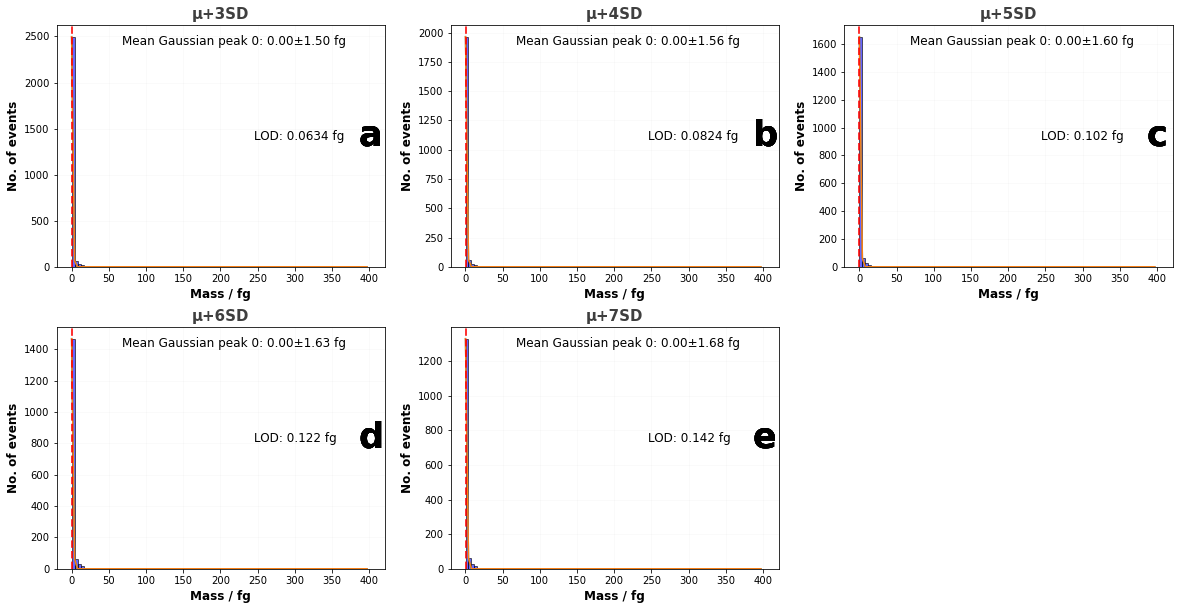

In [72]:
# Plot subplots for Nanoparticle Data
fig, ax = plt.subplots(figsize=(20,10))
fig.subplots_adjust(hspace=0.25, wspace=0.2)

masses_peaks_gaussian = []
info_masses_peaks_gaussian = []
all_power_lists_mass_gaussian = [] # for excel output
for p in sd_trials:
    q = p-sd_trials[0]
# Skip if no masses available
    if q >= len(masses_list) or masses_list[q] is None or LOD_list[q] is None:
        print(f"No masses for Gaussian µ+{p}SD.")
        continue
    plot = 231+q
    plt.subplot(plot)
    
    df_masses_SD = masses_list[q][1].value_counts().to_frame(name= 'Frequency')
    df_masses_SD = df_masses_SD.reset_index()
    df_masses_SD_final = df_masses_SD.sort_values(df_masses_SD.columns[0])[0]
    
    h = plt.hist(df_masses_SD_final, bins=100, color='blue', edgecolor='k',alpha=0.6)
    n = 1
    max_x = (max(h[1]))+50*(max(h[1]))
    popt, pcov = fit_n_gaussians(n, h[1][:-1], h[0], bounds = (0,max_x))
    CI,perr = alpha_error(n,popt,pcov,alpha_confidence) #confidence interval of all popt parameters: alpha error
    plt.plot(h[1][:-1],gaussians_1(h[1][:-1], *popt))  #change gaussian_n accordingly
    
    power_list_mass_gaussian = []
    for _ in range(n):
        #checking that the obtained peak is real: beta error calculation
        amp_hat = popt[n+_]
        amp_err = perr[n+_] 
        beta, power = beta_error(amp_hat, amp_err, alpha_confidence)
        power_list_mass_gaussian.append(round(power,2))
        #for a 95% confidence of identifying a "real" peak (k = 2):
        if power > 1 - alpha_confidence:
            plt.annotate('Mean Gaussian peak %d: %.2f\u00B1%.2f fg' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12, fontweight='bold')
        else:
            plt.annotate('Mean Gaussian peak %d: %.2f\u00B1%.2f fg' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12)
    plt.annotate('LOD: %s' %round_sig(LOD_list[q][1],3) + ' fg', xy=(0.6, 0.525), xycoords='axes fraction', fontsize=12)
    plt.grid(color= 'gray', alpha=0.05)
    plt.axvline(LOD_list[q][1], color='red', lw=2, ls='--', alpha=0.8)
    plt.xlabel('Mass / fg', fontsize=12, fontweight='semibold')
    plt.title(f'µ+{p}SD', fontsize=15, fontweight='semibold', alpha=0.75)

    plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    
    letter = ['a','b','c','d','e']
    for x in letter:
        plt.annotate(letter[q], xy=(0.92, 0.5), xycoords='axes fraction',fontweight= 'semibold',  fontsize=35)
            
    storage = save_data(p, n, popt, h[1][:-1], h[0], CI, power_list_mass_gaussian)
    masses_peaks_gaussian.append(storage[0])
    info_masses_peaks_gaussian.append(storage[1])
    all_power_lists_mass_gaussian.append(power_list_mass_gaussian) # for excel output
        
# Save figure
plt.savefig(new_name[0] + "_mass_histograms_gaussian" + ".png", bbox_inches='tight', dpi=300)

## Mass histograms (Poisson)

### !!! Adapt  line 18 (n = number of expected peaks);
### !!! line 19 "(max(h[1]))+"NUMBER"*(max(h[1]))(max(h[1]))+100*(max(h[1]))";
### !!! line 22 "gaussians_"n"" 

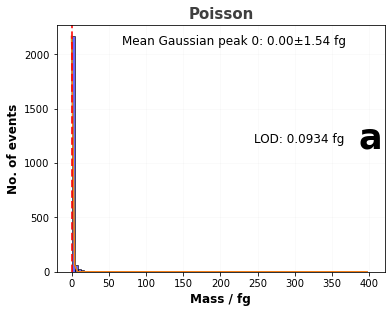

In [73]:
# Plot subplots for Nanoparticle Data
fig, ax = plt.subplots(figsize=(20,10))
fig.subplots_adjust(hspace=0.20, wspace=0.20)

masses_peaks_poisson = []
info_masses_peaks_poisson = []
all_power_lists_mass_poisson = [] # for excel output

for p in sd_trials[0:1]:
    q = p-sd_trials[0]
# Skip if no masses available
    if q >= len(masses_list_poisson) or masses_list_poisson[q] is None or LOD_list_poisson[q] is None:
        print(f"No masses for Poisson.")
        continue
    plot = 231+q
    plt.subplot(plot)
    
    df_masses_SD = masses_list_poisson[q][1].value_counts().to_frame(name= 'Frequency')
    df_masses_SD = df_masses_SD.reset_index()
    df_masses_SD_final = df_masses_SD.sort_values(df_masses_SD.columns[0])[0]

    h = plt.hist(df_masses_SD_final, bins=100, color='blue', edgecolor='k',alpha=0.6)
    n = 1
    max_x = (max(h[1]))+50*(max(h[1]))
    popt, pcov = fit_n_gaussians(n, h[1][:-1], h[0], bounds = (0,max_x))
    CI,perr = alpha_error(n,popt,pcov,alpha_confidence) #confidence interval of all popt parameters: alpha error
    plt.plot(h[1][:-1],gaussians_1(h[1][:-1], *popt))  #change gaussian_n accordingly
    
    power_list_mass_poisson=[]
    for _ in range(n):
        # Checking that the obtained peak is real: beta error calculation
        amp_hat = popt[n+_]
        amp_err = perr[n+_] 
        beta, power = beta_error(amp_hat, amp_err, alpha_confidence)
        power_list_mass_poisson.append(round(power,2))
        #for a 95% confidence of identifying a "real" peak (k = 2):
        if power > 1 - alpha_confidence:
            plt.annotate('Mean Gaussian peak %d: %.2f\u00B1%.2f fg' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12, fontweight='bold')
        else:
            plt.annotate('Mean Gaussian peak %d: %.2f\u00B1%.2f fg' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12)
    plt.annotate('LOD: %s' %round_sig(LOD_list_poisson[q][1],3) + ' fg', xy=(0.6, 0.525), xycoords='axes fraction', fontsize=12)
    #plt.legend(loc=[1.5,1.10], prop={'size':15})
    plt.grid(color= 'gray', alpha=0.05)
    plt.axvline(LOD_list_poisson[q][1], color='red', lw=2, ls='--', alpha=0.8)
    plt.xlabel('Mass / fg', fontsize=12, fontweight='semibold')
    plt.title('Poisson', fontsize=15, fontweight='semibold', alpha=0.75)
    plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    letter = ['a']
    
    for x in letter:
        plt.annotate(letter[q], xy=(0.92, 0.5), xycoords='axes fraction',fontweight= 'semibold',  fontsize=35)
    
    storage = save_data(p, n, popt, h[1][:-1], h[0], CI, power_list_mass_poisson)
    masses_peaks_poisson.append(storage[0])
    info_masses_peaks_poisson.append(storage[1])
    all_power_lists_mass_poisson.append(power_list_mass_poisson) # for excel output

plt.savefig(new_name[0] + "_mass_histograms_gaussian_poisson" + ".png", bbox_inches='tight', dpi=300)

## Size calculations (Gaussian)

In [74]:
def sizes(i):
    name = 'particle_size{}'.format(i)
    p = i-sd_trials[0]
    # Check if masses_list[p] exists, if not skip and print:
    if p >= len(masses_list) or masses_list[p] is None:
        print(f"No size data for Gaussian µ+{i}SD available.")
        return None
    diameter = ((((6 * masses_list[p][1] * f_d)/(math.pi * 10**15 * p_p)))**(1/3)) * 10**7 # in nm
    mean_diameter = np.mean(diameter)
    median_diameter = np.median(diameter)
    mode_diameter = stats.mode(diameter[0])
    sd = np.std(diameter)
    return name, diameter, mean_diameter, median_diameter, mode_diameter, sd
sizes_list = []

for i in sd_trials:
    result = sizes(i)
    if result is not None:
        sizes_list.append(result)

##Particle diameters => sizes_list[p][1]
##Mean diameter => sizes_list[p][2]
##Median diameter => sizes_list[p][3]
##Mode diameter => sizes_list[p][4]
##SD diameter => sizes_list[p][5]

## Size calculations (Poisson)

In [75]:
def sizes_poisson(i):
    name = 'particle_size_poisson{}'.format(i)
    p = i-sd_trials[0]
    # Check if masses_list_poisson[p] exists, if not skip and print
    if p >= len(masses_list_poisson) or masses_list_poisson[p] is None:
        print(f"No size data for Poisson available.")
        return None
    diameter = ((((6 * masses_list_poisson[p][1] * f_d)/(math.pi * 10**15 * p_p)))**(1/3)) * 10**7 # in nm
    mean_diameter = np.mean(diameter)
    median_diameter = np.median(diameter)
    mode_diameter = stats.mode(diameter[0])
    sd = np.std(diameter)
    return name, diameter, mean_diameter, median_diameter, mode_diameter, sd
sizes_list_poisson = []

for i in sd_trials[0:1]:
    result = sizes_poisson(i)
    if result is not None:
        sizes_list_poisson.append(result)

##Particle diameters => sizes_list_poisson[p][1]
##Mean diameter => sizes_list_poisson[p][2]
##Median diameter => sizes_list_poisson[p][3]
##Mode diameter => sizes_list_poisson[p][4]
##Sd diameter => sizes_list_poisson[p][5]

## Size histograms (Gaussian)

### !!! Adapt  line 18 (n = number of expected peaks);
### !!! line 19 "(max(h[1]))+"NUMBER"*(max(h[1]))(max(h[1]))+100*(max(h[1]))";
### !!! line 22 "gaussians_"n"" 

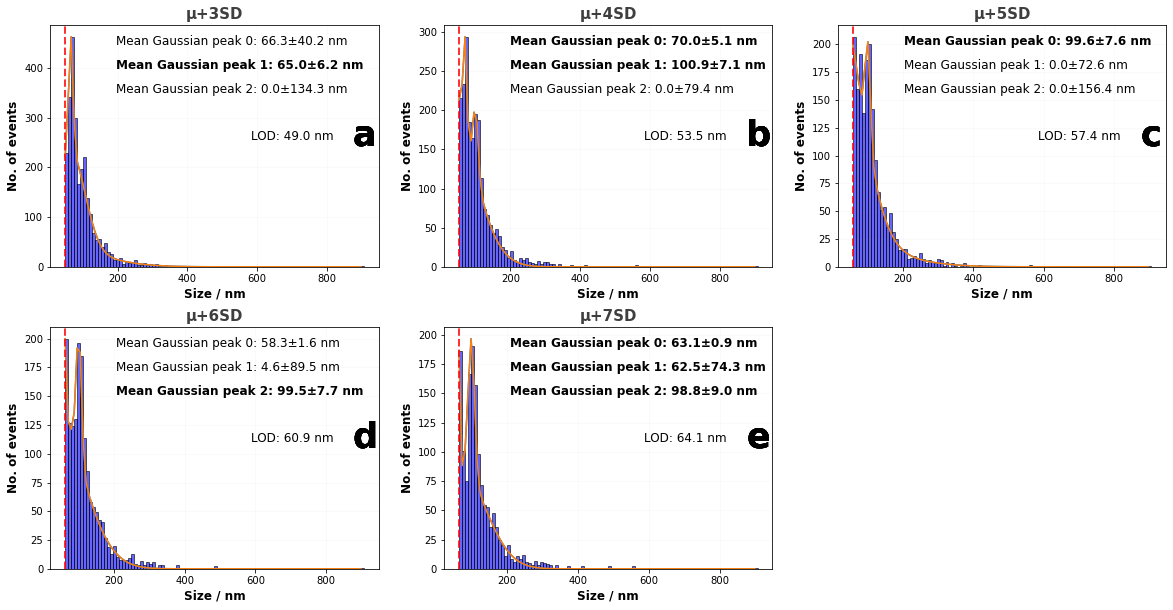

In [76]:
# Plot subplots for Nanoparticle Data
fig, ax = plt.subplots(figsize=(20,10))
fig.subplots_adjust(hspace=0.25, wspace=0.20)

sizes_peaks_gaussian = []
info_sizes_peaks_gaussian = []
all_power_lists_size_gaussian = [] # for excel output
for p in sd_trials:
    q = p-sd_trials[0]
# Skip empty or missing data
    if q >= len(sizes_list) or sizes_list[q] is None:
        print(f"No size data for Gaussian µ+{p}SD available.")
        continue
        
    plot = 231+q
    plt.subplot(plot)
    
    df_sizes_SD = sizes_list[q][1].value_counts().to_frame(name= 'Frequency')
    df_sizes_SD = df_sizes_SD.reset_index()
    df_sizes_SD_final = df_sizes_SD.sort_values(df_sizes_SD.columns[0])[0]
    
    h = plt.hist(df_sizes_SD_final, bins=100, color='blue', edgecolor='k',alpha=0.6)
    n = 3
    max_x = int(max(h[1]))+0.01*int(max(h[1]))
    popt, pcov = fit_n_gaussians(n, h[1][:-1], h[0], bounds = (0, max_x))
    CI,perr = alpha_error(n,popt,pcov,alpha_confidence) #confidence interval of all popt parameters: alpha error
    plt.plot(h[1][:-1],gaussians_3(h[1][:-1], *popt))  #change gaussian_n accordingly
    
    power_list_size_gaussian = []
    for _ in range(n):
        amp_hat = popt[n+_]
        amp_err = perr[n+_] 
        beta, power = beta_error(amp_hat, amp_err, alpha_confidence)
        power_list_size_gaussian.append(round(power,2))
        #for a 95% confidence of identifying a "real" peak (k = 2):
        if power > 1 - alpha_confidence:
            plt.annotate('Mean Gaussian peak %d: %.1f\u00B1%.1f nm' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12, fontweight='bold')
        else:
            plt.annotate('Mean Gaussian peak %d: %.1f\u00B1%.1f nm' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12)
    plt.annotate('LOD: %s' %round_sig(LOD_list[q][2],3) + ' nm', xy=(0.61, 0.525), xycoords='axes fraction', fontsize=12)
    #plt.legend(loc=[1.5,1.10], prop={'size':15})
    plt.grid(color= 'gray', alpha=0.05)
    plt.axvline(LOD_list[q][2], color='red', lw=2, ls='--', alpha=0.8)
    plt.xlabel('Size / nm', fontsize=12, fontweight='semibold')
    plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    plt.title(f'µ+{p}SD', fontsize=15, fontweight='semibold', alpha=0.75)
    letter = ['a','b','c','d','e']
    for x in letter:
        plt.annotate(letter[q], xy=(0.92, 0.5), xycoords='axes fraction',fontweight= 'semibold',  fontsize=35)
    
    storage = save_data(p, n, popt, h[1][:-1], h[0], CI, power_list_size_gaussian)
    sizes_peaks_gaussian.append(storage[0])
    info_sizes_peaks_gaussian.append(storage[1])
    all_power_lists_size_gaussian.append(power_list_size_gaussian) # for excel output
    
plt.savefig(new_name[0] + "_size_histograms_gaussian" + ".png", bbox_inches='tight', dpi=300)

## Size histograms (Poisson)

### !!! Adapt  line 18 (n = number of expected peaks);
### !!! line 19 "(max(h[1]))+"NUMBER"*(max(h[1]))(max(h[1]))+100*(max(h[1]))";
### !!! line 22 "gaussians_"n"" 

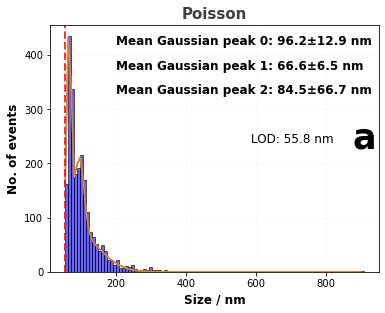

In [77]:
# Plot subplots for Nanoparticle Data
fig, ax = plt.subplots(figsize=(20,10))
fig.subplots_adjust(hspace=0.2, wspace=0.2)

sizes_peaks_poisson = []
info_sizes_peaks_poisson = []
all_power_lists_size_poisson = [] # for excel output

for p in sd_trials[0:1]:
    q = p-sd_trials[0]
# Skip empty or missing data
    if q >= len(sizes_list_poisson) or sizes_list_poisson[q] is None:
        print(f"No size data for Poisson available.")
        continue
    plot = 231+q
    plt.subplot(plot)
    
    df_sizes_SD = sizes_list_poisson[q][1].value_counts().to_frame(name= 'Frequency')
    df_sizes_SD = df_sizes_SD.reset_index()
    df_sizes_SD_final = df_sizes_SD.sort_values(df_sizes_SD.columns[0])[0]
    
    h = plt.hist(df_sizes_SD_final, bins=100, color='blue', edgecolor='k',alpha=0.6)
    n = 3
    max_x = int(max(h[1]))+0.01*int(max(h[1]))
    popt, pcov = fit_n_gaussians(n, h[1][:-1], h[0], bounds = (0,max_x))
    CI,perr = alpha_error(n,popt,pcov,alpha_confidence) #confidence interval of all popt parameters: alpha error
    plt.plot(h[1][:-1],gaussians_3(h[1][:-1], *popt))  #change gaussian_n accordingly
    
    power_list_size_poisson = []
    for _ in range(n):
        amp_hat = popt[n+_]
        amp_err = perr[n+_] 
        beta, power = beta_error(amp_hat, amp_err, alpha_confidence)
        power_list_size_poisson.append(round(power,2))
        #for a 95% confidence of identifying a "real" peak (k = 2):
        if power > 1 - alpha_confidence:
            plt.annotate('Mean Gaussian peak %d: %.1f\u00B1%.1f nm' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12, fontweight='bold')
        else:
            plt.annotate('Mean Gaussian peak %d: %.1f\u00B1%.1f nm' % # %.2f controls the number of digits
                         (_, popt[n+_], popt[2*n+_]),
                         xy=(0.2, 0.92 - (_ * 0.1)),
                         xycoords='axes fraction', fontsize=12)
    plt.annotate('LOD: %s' %round_sig(LOD_list_poisson[q][2],3) + ' nm', xy=(0.61, 0.525), xycoords='axes fraction', fontsize=12)
    #plt.legend(loc=[1.5,1.10], prop={'size':15})
    plt.grid(color= 'gray', alpha=0.05)
    plt.axvline(LOD_list_poisson[q][2], color='red', lw=2, ls='--', alpha=0.8)    
    plt.xlabel('Size / nm', fontsize=12, fontweight='semibold')
    plt.ylabel('No. of events', fontsize=12, fontweight='semibold')
    plt.title('Poisson', fontsize=15, fontweight='semibold', alpha=0.75)

    letter = ['a']
    for x in letter:
        plt.annotate(letter[q], xy=(0.92, 0.5), xycoords='axes fraction',fontweight= 'semibold',  fontsize=35)
            
    storage = save_data(p, n, popt, h[1][:-1], h[0], CI, power_list_size_poisson)
    sizes_peaks_poisson.append(storage[0])
    info_sizes_peaks_poisson.append(storage[1])
    all_power_lists_size_poisson.append(power_list_size_poisson) # for excel output

        
plt.savefig(new_name[0] + "_size_histograms_gaussian_poisson" + ".png", bbox_inches='tight', dpi=300)

# Particle mass concentrations

## Gaussian

In [78]:
def mass_conc(i):
    p = i-sd_trials[0]
    if p >= len(masses_list) or masses_list[p] is None:
        print(f"No particle mass concentration data available for Gaussian µ+{i}SD.")
        return None
    name = 'mass_conc. µ+{}'.format(i)+'SD'
    mass_conc_sum = ((np.sum(masses_list[p][1])[0])*(10**3)/(flow*te*total_aquisition_time))*DF*10**-12 # masses in masses_list in fg
    mass_conc_mean = (masses_list[p][2] * event_number_list[p][4] * 10**-3)*10**-6 # DF is already in "event_number_list"
    return name, mass_conc_sum, mass_conc_mean
mass_conc_list = []
for i in sd_trials:
    result = mass_conc(i)
    if result is not None:
        mass_conc_list.append(result)
        
for p in range(len(mass_conc_list)):
    print('Mass conc. [via sum] (Gaussian µ + {}SD) [mg/L]  = '.format(sd_trials[p]), mass_conc_list[p][1])
    print('Mass conc. [via mean] (Gaussian µ + {}SD) [mg/L] = '.format(sd_trials[p]), mass_conc_list[p][2][0])
    
##Mass concentration (via sum) => mass_conc_list[p][1]
##Mass concentration (via mean) => mass_conc_list[p][2]

Mass conc. [via sum] (Gaussian µ + 3SD) [mg/L]  =  123224.06547839464
Mass conc. [via mean] (Gaussian µ + 3SD) [mg/L] =  123224.06547839486
Mass conc. [via sum] (Gaussian µ + 4SD) [mg/L]  =  117755.89727615615
Mass conc. [via mean] (Gaussian µ + 4SD) [mg/L] =  117755.89727615617
Mass conc. [via sum] (Gaussian µ + 5SD) [mg/L]  =  115034.50081229523
Mass conc. [via mean] (Gaussian µ + 5SD) [mg/L] =  115034.50081229517
Mass conc. [via sum] (Gaussian µ + 6SD) [mg/L]  =  113195.25224686411
Mass conc. [via mean] (Gaussian µ + 6SD) [mg/L] =  113195.25224686426
Mass conc. [via sum] (Gaussian µ + 7SD) [mg/L]  =  111784.69671082779
Mass conc. [via mean] (Gaussian µ + 7SD) [mg/L] =  111784.6967108277


## Poisson

In [79]:
def mass_conc_poisson(i):
    p = i-sd_trials[0]
    if p >= len(masses_list_poisson) or masses_list_poisson[p] is None:
        print(f"No particle mass concentration data available for Poisson.")
        return None
    name_poisson = 'mass_conc. µ+{}'.format(i)+'SD'
    mass_conc_sum_poisson = ((np.sum(masses_list_poisson[p][1])[0])*(10**3)/(flow*te*total_aquisition_time))*DF*10**-12 # masses in masses_list in fg
    mass_conc_mean_poisson = (masses_list_poisson[p][2][0] * event_number_list_poisson[p][4] * 10**-3)*10**-6 # DF is already in "event_number_list"
    return name_poisson, mass_conc_sum_poisson, mass_conc_mean_poisson
mass_conc_list_poisson = []
for i in sd_trials:
    result = mass_conc_poisson(i)
    if result is not None:
        mass_conc_list_poisson.append(result)

if not mass_conc_list_poisson:
    print("No Poisson mass concentration data available.")
else:
    for p in range(len(mass_conc_list_poisson)):
        print('Mass conc. [via sum] (Poisson) [mg/L]  =', mass_conc_list_poisson[p][1])
        print('Mass conc. [via mean] (Poisson) [mg/L] =', mass_conc_list_poisson[p][2])
    
##Mass concentration (via sum) => mass_conc_list_poisson[p][1]
##Mass concentration (via mean) => mass_conc_list_poisson[p][2]

No particle mass concentration data available for Poisson.
No particle mass concentration data available for Poisson.
No particle mass concentration data available for Poisson.
No particle mass concentration data available for Poisson.
Mass conc. [via sum] (Poisson) [mg/L]  = 118384.38026121026
Mass conc. [via mean] (Poisson) [mg/L] = 118384.38026121024


## Save Mean, median, mode and SD for masses and sizes

### Gaussian

In [80]:
##Particle diameters => sizes_list[p][1]
##Mean diameter => sizes_list[p][2]
##Median diameter => sizes_list[p][3]
##Mode diameter => sizes_list[p][4]
##SD diameter => sizes_list[p][5]

#Gaussian 'masses_list_export_(µ+{}SD)[fg]'.format(p)
def masses_sizes_summary_excel(i):
    p = i - sd_trials[0]
    name = 'masses_summary{}'.format(i)
    
    # Initialize empty lists in case of missing data
    masses_list_excel = [np.nan, np.nan, np.nan, None]
    sizes_list_excel = [np.nan, np.nan, np.nan, None]
    
    # Process masses
    if p < len(masses_list) and masses_list[p] is not None and len(masses_list[p][1]) > 0:
        mass_data = masses_list[p][1][0]
        masses_list_excel = [
            round_sig(np.mean(mass_data), 3),
            round_sig(np.median(mass_data), 3),
            round_sig(np.std(mass_data), 3),
            stats.mode(np.round(mass_data, 2))
        ]
    
    # Process sizes
    if p < len(sizes_list) and sizes_list[p] is not None and len(sizes_list[p][1]) > 0:
        size_data = sizes_list[p][1][0]
        sizes_list_excel = [
            round_sig(np.mean(size_data), 3),
            round_sig(np.median(size_data), 3),
            round_sig(np.std(size_data), 3),
            stats.mode(np.round(size_data, 2))
        ]
    
    return name, masses_list_excel, sizes_list_excel

masses_sizes_list_excel = []

for i in sd_trials:
    result = masses_sizes_summary_excel(i)
    masses_sizes_list_excel.append(result)

# Get masses from masses_sizes_list_excel[p][1]
# Get sizes from masses_sizes_list_excel[p][2]

### Poisson

In [81]:
##Particle diameters => sizes_list[p][1]
##Mean diameter => sizes_list[p][2]
##Median diameter => sizes_list[p][3]
##Mode diameter => sizes_list[p][4]
##SD diameter => sizes_list[p][5]

#Gaussian 'masses_list_export_(µ+{}SD)[fg]'.format(p)
def masses_sizes_summary_excel_poisson(i):
    p = i - sd_trials[0]
    name = 'masses_summary_poisson{}'.format(i)
    
    # Initialize empty lists in case of missing data
    masses_list_excel_poisson = [np.nan, np.nan, np.nan, None]
    sizes_list_excel_poisson = [np.nan, np.nan, np.nan, None]
    
    # Process masses
    if p < len(masses_list_poisson) and masses_list_poisson[p] is not None and len(masses_list_poisson[p][1]) > 0:
        mass_data = masses_list_poisson[p][1][0]
        masses_list_excel_poisson = [
            round_sig(np.mean(mass_data), 3),
            round_sig(np.median(mass_data), 3),
            round_sig(np.std(mass_data), 3),
            stats.mode(np.round(mass_data, 2))
        ]
    
    # Process sizes
    if p < len(sizes_list_poisson) and sizes_list_poisson[p] is not None and len(sizes_list_poisson[p][1]) > 0:
        size_data = sizes_list_poisson[p][1][0]
        sizes_list_excel_poisson = [
            round_sig(np.mean(size_data), 3),
            round_sig(np.median(size_data), 3),
            round_sig(np.std(size_data), 3),
            stats.mode(np.round(size_data, 1))
        ]
    
    return name, masses_list_excel_poisson, sizes_list_excel_poisson

masses_sizes_list_excel_poisson = []

for i in sd_trials[0:1]:
    result = masses_sizes_summary_excel_poisson(i)
    masses_sizes_list_excel_poisson.append(result)

# Get masses from masses_sizes_list_excel_poisson[p][1]
# Get sizes from masses_sizes_list_excel_poisson[p][2]

## Save data into Excel file

In [82]:
#Print 'no data' in empty cells
def safe_get(lst, outer_idx=None, inner_idx=None):
    try:
        if outer_idx is None:
            return lst
        if inner_idx is None:
            return lst[outer_idx]
        return lst[outer_idx][inner_idx]
    except (IndexError, TypeError):
        return 'No data'

def safe_df(data, **kwargs):
    safe_data = []
    for row in data:
        if isinstance(row, (list, tuple, pd.Series)):
            safe_data.append([safe_get(v) for v in row])
        else:
            safe_data.append([safe_get(row)])
    return pd.DataFrame(safe_data, **kwargs)

def safe_df_from_list(data_list, outer_idx, inner_idx):
    df = safe_get(data_list, outer_idx, inner_idx)
    if isinstance(df, pd.DataFrame):
        if not df.empty:
            first_col = df.columns[0]
            df = df.sort_values(first_col).reset_index(drop=True)
        return df
    return pd.DataFrame(['No data'])

def safe_df_from_info(lst, outer_idx, inner_idx):
    try:
        return safe_df([lst[outer_idx][inner_idx]])
    except IndexError:
        # Return empty DataFrame with one row so concat works
        return safe_df([[]])
#For the sizes summary part
def merge_sizes(aaa, aa, mass_idx):
    df = pd.concat([aaa, aa], axis=0, ignore_index=True)
    mass_df = safe_df_from_list(mass_conc_list, mass_idx, 1)
    # ------------------ CRUCIAL: Ensure 'No data' is only filled if mass_df is shorter ------------------
    df = df.reindex(range(max(len(df), len(mass_df))), fill_value='No data')
    df.iloc[:len(mass_df), 0] = mass_df.values[:, 0]  # Keep actual mass_conc values
    return df
    
# Change figure size
def calculate_scale(file_path, bound_size):
    # check the image size without loading it into memory
    im = Image.open(file_path)
    original_width, original_height = im.size

    # calculate the resize factor, keeping original aspect and staying within boundary
    bound_width, bound_height = bound_size
    ratios = (float(bound_width) / original_width, float(bound_height) / original_height)
    return min(ratios)

name = new_name[0]+'_output.xlsx'
# define excel write function
writer = pd.ExcelWriter(name, engine='xlsxwriter')

####################### Baseline correction #######################
df=safe_df([ionic_mode_est], columns=['Ionic mode estimation (CPS)'])
df.to_excel(writer, sheet_name="Baseline correction", index=False)
worksheet = writer.sheets['Baseline correction']
worksheet.set_tab_color('magenta')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Baseline correction'].set_column(col_idx, col_idx, column_length)
resize_scale = calculate_scale(new_name[0] + "_baseline_correction" + ".png", (1800,1800))
worksheet.insert_image('A3', new_name[0] + "_baseline_correction" + ".png", {'x_scale': resize_scale, 'y_scale': resize_scale}) # Insert image

####################### PDT (Gaussian) #######################
A = safe_df([PDT3])
B = safe_df([PDT4])
C = safe_df([PDT5])
D = safe_df([PDT6])
E = safe_df([PDT7])
columns = [new_name[0]+'_µ+3SD_spICP-MS_(CPS)',new_name[0]+'_µ+4SD_spICP-MS_(CPS)',new_name[0]+'_µ+5SD_spICP-MS_(CPS)',new_name[0]+'_µ+6SD_spICP-MS_(CPS)',new_name[0]+'_µ+7SD_spICP-MS_(CPS)']
df = pd.concat([A,B,C,D,E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="PDT_Gaussian", index=False)
worksheet = writer.sheets['PDT_Gaussian']
worksheet.set_tab_color('green')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['PDT_Gaussian'].set_column(col_idx, col_idx, column_length)
#Transfer .gif in .png for Excel
gif_file = new_name[0] + "_time_zoom_gaussian.gif"
png_file = new_name[0] + "_time_zoom_gaussian.png"
with Image.open(gif_file) as im:
    im.seek(0)  # first frame
    im.save(png_file, format='PNG', dpi=(300, 300))
resize_scale = calculate_scale(png_file, (2800,2800))
worksheet.insert_image('A4', png_file, {'x_scale': resize_scale, 'y_scale': resize_scale}) # Insert image

####################### LC & PDT (Poisson) #######################
Index = safe_df(['Critical value (LC)', 'Particle Detection Threshold (PDT)'])
A = safe_df([poisson_limits[0][1], poisson_limits[0][2]])
columns = ['Parameter', new_name[0]+'_Poisson_spICP-MS_(CPS)']
df = pd.concat([Index,A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="PDT_LC_Poisson", index=False)
worksheet = writer.sheets['PDT_LC_Poisson']
worksheet.set_tab_color('green') # Set Tab Colour
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['PDT_LC_Poisson'].set_column(col_idx, col_idx, column_length)
#Transfer .gif in .png for Excel
gif_file = new_name[0] + "_time_zoom_poisson.gif"
png_file = new_name[0] + "_time_zoom_poisson.png"
with Image.open(gif_file) as im:
    im.seek(0)  # first frame
    im.save(png_file, format='PNG', dpi=(300, 300))
resize_scale = calculate_scale(png_file, (1200,1200))
worksheet.insert_image('A4', png_file, {'x_scale': resize_scale, 'y_scale': resize_scale}) # Insert image    
   
####################### Particle raw signals (Gaussian) #######################
A = safe_df_from_list(outliers_particles_data, 0, 2)
B = safe_df_from_list(outliers_particles_data, 1, 2)
C = safe_df_from_list(outliers_particles_data, 2, 2)
D = safe_df_from_list(outliers_particles_data, 3, 2)
E = safe_df_from_list(outliers_particles_data, 4, 2)
columns = [new_name[0]+'_µ+3SD_spICP-MS_(CPS)',new_name[0]+'_µ+4SD_spICP-MS_(CPS)',new_name[0]+'_µ+5SD_spICP-MS_(CPS)',new_name[0]+'_µ+6SD_spICP-MS_(CPS)',new_name[0]+'_µ+7SD_spICP-MS_(CPS)']
df = pd.concat([A,B,C,D,E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Raw_Gaussian", index=False)
worksheet = writer.sheets['Raw_Gaussian']
worksheet.set_tab_color('yellow')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Raw_Gaussian'].set_column(col_idx, col_idx, column_length)
resize_scale = calculate_scale(new_name[0] + "_sums_zoom_gaussian" + ".png", (2000,2000))
worksheet.insert_image('F1', new_name[0] + "_sums_zoom_gaussian" + ".png", {'x_scale': resize_scale, 'y_scale': resize_scale}) # Insert image

####################### Particle raw signals (Poisson) #######################
A = safe_df_from_list(outliers_particles_data_poisson, 0, 2)
columns = [new_name[0]+'_Poisson_spICP-MS_(CPS)']
df = pd.concat([A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Raw_Poisson", index=False)
worksheet = writer.sheets['Raw_Poisson']
worksheet.set_tab_color('yellow')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Raw_Poisson'].set_column(col_idx, col_idx, column_length)
resize_scale = calculate_scale(new_name[0] + "_sums_zoom_poisson" + ".png", (1200,1200))
worksheet.insert_image('B1', new_name[0] + "_sums_zoom_poisson" + ".png", {'x_scale': resize_scale, 'y_scale': resize_scale}) # Insert image

####################### Particle number conc. (Gaussian) #######################
A = safe_df([safe_get(event_number_list,0,4)])
B = safe_df([safe_get(event_number_list,1,4)])
C = safe_df([safe_get(event_number_list,2,4)])
D = safe_df([safe_get(event_number_list,3,4)])
E = safe_df([safe_get(event_number_list,4,4)])
columns = [new_name[0]+'_µ+3SD_spICP-MS_(NP/mL)',new_name[0]+'_µ+4SD_spICP-MS_(NP/mL)',new_name[0]+'_µ+5SD_spICP-MS_(NP/mL)',new_name[0]+'_µ+6SD_spICP-MS_(NP/mL)',new_name[0]+'_µ+7SD_spICP-MS_(NP/mL)']
df = pd.concat([A,B,C,D,E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Number_conc_Gaussian", index=False)
worksheet = writer.sheets['Number_conc_Gaussian']
worksheet.set_tab_color('blue')
# Exponential cell type in excel
workbook = writer.book
format1 = workbook.add_format({"num_format": "0.00E+0"})
worksheet.set_column(0, 4, 28, format1)
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Number_conc_Gaussian'].set_column(col_idx, col_idx, column_length)

####################### Particle number conc. (Poisson) #######################
# Safe handling for missing data
A = safe_df_from_info(event_number_list_poisson, 0, 4)
# Ensure A has at least one column
if A.empty or A.shape[1] == 0:
    A = pd.DataFrame(['No data'])
columns = [new_name[0]+'_Poisson_spICP-MS_(NP/mL)']
df = pd.concat([A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Number_conc_Poisson", index=False)
worksheet = writer.sheets['Number_conc_Poisson']
worksheet.set_tab_color('blue')
# Exponential cell type in excel
workbook = writer.book
format1 = workbook.add_format({"num_format": "0.00E+0"})
worksheet.set_column(0, 4, 28, format1)
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Number_conc_Poisson'].set_column(col_idx, col_idx, column_length)

####################### Masses (Gaussian) (whole dataset) #######################
A = safe_df_from_list(masses_list, 0, 1)
B = safe_df_from_list(masses_list, 1, 1)
C = safe_df_from_list(masses_list, 2, 1)
D = safe_df_from_list(masses_list, 3, 1)
E = safe_df_from_list(masses_list, 4, 1)
columns = [new_name[0]+'_µ+3SD_spICP-MS_(fg)',new_name[0]+'_µ+4SD_spICP-MS_(fg)',new_name[0]+'_µ+5SD_spICP-MS_(fg)',new_name[0]+'_µ+6SD_spICP-MS_(fg)',new_name[0]+'_µ+7SD_spICP-MS_(fg)']
df = pd.concat([A,B,C,D,E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Masses_Gaussian", index=False)
worksheet = writer.sheets['Masses_Gaussian']
worksheet.set_tab_color('red')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Masses_Gaussian'].set_column(col_idx, col_idx, column_length)

####################### Masses (Poisson) (whole dataset) #######################
A = safe_df_from_list(masses_list_poisson, 0, 1)
columns = [new_name[0]+'_Poisson_spICP-MS_(fg)']
df = pd.concat([A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Masses_Poisson", index=False)
worksheet = writer.sheets['Masses_Poisson']
worksheet.set_tab_color('red')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Masses_Poisson'].set_column(col_idx, col_idx, column_length)    
    
####################### Masses (Gaussian) (Peak fitting) #######################
# Function to parse and convert strings to a DataFrame, filtering out empty strings
def parse_strings_to_dataframe(strings):
    def parse_and_filter(s):
        inner_list = ast.literal_eval(s)
        return [float(item) for item in inner_list if str(item).strip()]
    return pd.DataFrame([parse_and_filter(s) for s in strings]).T  # numeric

# Create DataFrames from masses_peaks_gaussian
dataframes = [df for df in (parse_strings_to_dataframe(s) for s in masses_peaks_gaussian) if df is not None and not df.empty]

if dataframes:  # Only concat if we have at least one DataFrame
    df = pd.concat(dataframes, axis=1)
else:
    df = pd.DataFrame(['No data'])
# Generate column names
num_columns = df.shape[1]
SD_columns=[3,3,3,3,4,4,4,4,5,5,5,5,6,6,6,6,7,7,7,7]
columns = [
    f"{new_name[0][:-2]}_Peak_{i % 4}_µ+{SD_columns[i]}SD_spICP-MS_(fg)" 
    for i in range(num_columns)
]
df.columns = columns

df.to_excel(writer, sheet_name="Masses_Gaussian_Peaks", index=False)
worksheet = writer.sheets['Masses_Gaussian_Peaks']
worksheet.set_tab_color('red')

# Set column widths
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)

# Insert histogram image
resize_scale = calculate_scale(new_name[0] + "_mass_histograms_gaussian.png", (2400,2400))
worksheet.insert_image('A25', new_name[0] + "_mass_histograms_gaussian.png", {'x_scale': resize_scale, 'y_scale': resize_scale})

####################### Masses (Poisson) (Peak fitting) #######################
# Create DataFrames from masses_peaks_poisson
dataframes = [parse_strings_to_dataframe(strings) for strings in masses_peaks_poisson]

if not dataframes or all(df.empty for df in dataframes):
    # If list is empty or all DataFrames are empty, create placeholder
    df = pd.DataFrame(['No data'])
else:
    df = pd.concat(dataframes, axis=1)

# Generate column names
num_columns = df.shape[1]
columns = [f"{new_name[0]}_Peak_{i % 4}_Poisson_spICP-MS_(fg)" for i in range(num_columns)]
df.columns = columns

df.to_excel(writer, sheet_name="Masses_Poisson_Peaks", index=False)
worksheet = writer.sheets['Masses_Poisson_Peaks']
worksheet.set_tab_color('red')

# Set column widths (same as Gaussian)
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)

# Insert histogram
resize_scale = calculate_scale(new_name[0] + "_mass_histograms_gaussian_poisson.png", (1200,1200))
worksheet.insert_image('A25', new_name[0] + "_mass_histograms_gaussian_poisson.png",
                       {'x_scale': resize_scale, 'y_scale': resize_scale})

####################### Masses summary, whole dataset (Gaussian) Mean, Median, Mode, SD AND Peak fitting: Average + 2 SD  #######################
Index = pd.DataFrame(['Mean', 'Median', 'SD', 'Mode', 'Peak 0', 'Peak 1', 'Peak 2', 'Peak 3'])
#For mean, median, SD, Mode
def safe_sizes_column(sizes_list, sample_idx, total_rows=4):
    if sample_idx < len(sizes_list):
        data = sizes_list[sample_idx][1]  # numeric list
        data_extended = []
        for d in data:
            if d is None or (isinstance(d, float) and np.isnan(d)):
                data_extended.append('No masses available')
            else:
                data_extended.append(d)
        # pad to total_rows
        data_extended += ['-'] * (total_rows - len(data_extended))
    else:
        data_extended = ['-'] * total_rows
    return pd.DataFrame(data_extended, dtype=object)
#For the peaks
def safe_df_from_info(info_list, sample_idx, total_peaks=4):
    if sample_idx < len(info_list):
        peaks = info_list[sample_idx]
        peaks_extended = [p if p is not None else float('nan') for p in peaks] + ['-'] * (total_peaks - len(peaks))
        return pd.DataFrame(peaks_extended[:total_peaks])
    else:
        return pd.DataFrame(['-'] * total_peaks)

AAA = safe_sizes_column(masses_sizes_list_excel, 0)
BBB = safe_sizes_column(masses_sizes_list_excel, 1)
CCC = safe_sizes_column(masses_sizes_list_excel, 2)
DDD = safe_sizes_column(masses_sizes_list_excel, 3)
EEE = safe_sizes_column(masses_sizes_list_excel, 4)

A_peaks = safe_df_from_info(info_masses_peaks_gaussian, 0)
B_peaks = safe_df_from_info(info_masses_peaks_gaussian, 1)
C_peaks = safe_df_from_info(info_masses_peaks_gaussian, 2)
D_peaks = safe_df_from_info(info_masses_peaks_gaussian, 3)
E_peaks = safe_df_from_info(info_masses_peaks_gaussian, 4)

A = pd.concat([AAA, A_peaks], axis=0).reset_index(drop=True)
B = pd.concat([BBB, B_peaks], axis=0).reset_index(drop=True)
C = pd.concat([CCC, C_peaks], axis=0).reset_index(drop=True)
D = pd.concat([DDD, D_peaks], axis=0).reset_index(drop=True)
E = pd.concat([EEE, E_peaks], axis=0).reset_index(drop=True)

columns = ['Parameter',
           new_name[0]+'_µ+3SD_spICP-MS_(fg)',
           new_name[0]+'_µ+4SD_spICP-MS_(fg)',
           new_name[0]+'_µ+5SD_spICP-MS_(fg)',
           new_name[0]+'_µ+6SD_spICP-MS_(fg)',
           new_name[0]+'_µ+7SD_spICP-MS_(fg)']

df = pd.concat([Index, A, B, C, D, E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Masses_Summary_Gaussian", index=False)
worksheet = writer.sheets['Masses_Summary_Gaussian']
worksheet.set_tab_color('red')
# Adjust column widths
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)
workbook = writer.book
bold_format = workbook.add_format({'bold': True})
start_row_for_peaks = 4  # Peak 0 corresponds to row index 4
for col_idx, power_list in enumerate(all_power_lists_mass_gaussian, start=1):  # start=1 because col 0 is 'Parameter'
    for i, power in enumerate(power_list):
        if power > 1 - alpha_confidence:  # same logic as plot
            row_idx = start_row_for_peaks + i
            worksheet.write(row_idx + 1, 0, df.iloc[row_idx, 0], bold_format)  # Parameter column
            worksheet.write(row_idx + 1, col_idx, df.iloc[row_idx, col_idx], bold_format)  # sample column
    
####################### Masses summary, whole dataset (Poisson) Mean, Median, Mode, SD AND Peak fitting: Average + 2 SD #######################
Index = pd.DataFrame(['Mean', 'Median', 'SD', 'Mode', 'Peak 0', 'Peak 1', 'Peak 2', 'Peak 3'])
#For mean, median, SD, Mode
def safe_sizes_column(sizes_list, sample_idx, total_rows=4):
    if sample_idx < len(sizes_list):
        data = sizes_list[sample_idx][1]
        data_extended = [d if d is not None and not pd.isna(d) else '-' for d in data]
        data_extended += ['-'] * (total_rows - len(data_extended))
        return pd.DataFrame(data_extended[:total_rows])
    else:
        return pd.DataFrame(['-'] * total_rows)
# For the peaks
def safe_df_from_info(info_list, sample_idx, total_peaks=4):
    if sample_idx < len(info_list):
        peaks = info_list[sample_idx]
        peaks_extended = [p if p is not None else float('nan') for p in peaks] + ['-'] * (total_peaks - len(peaks))
        return pd.DataFrame(peaks_extended[:total_peaks])
    else:
        return pd.DataFrame(['-'] * total_peaks)

AAA = safe_sizes_column(masses_sizes_list_excel_poisson, 0, total_rows=4)
AA = safe_df_from_info(info_masses_peaks_poisson, 0, total_peaks=4)
A = pd.concat([AAA, AA], axis=0).reset_index(drop=True)
columns = ['Parameter', new_name[0]+'_Poisson_spICP-MS_(fg)']
df = pd.concat([Index, A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Masses_Summary_Poisson", index=False)
worksheet = writer.sheets['Masses_Summary_Poisson']
worksheet.set_tab_color('red')
# Auto-adjust column width
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)
workbook = writer.book
bold_format = workbook.add_format({'bold': True})
start_row_for_peaks = 4  # Peak 0 corresponds to row index 4
for col_idx, power_list in enumerate(all_power_lists_mass_poisson, start=1):  # start=1 because col 0 is 'Parameter'
    for i, power in enumerate(power_list):
        if power > 1 - alpha_confidence:  # same logic as plot
            row_idx = start_row_for_peaks + i
            worksheet.write(row_idx + 1, 0, df.iloc[row_idx, 0], bold_format)  # Parameter column
            worksheet.write(row_idx + 1, col_idx, df.iloc[row_idx, col_idx], bold_format)  # sample column
        
####################### Masses LOD (Gaussian) #######################
# Wrap each LOD value safely
A = safe_df([LOD_list[0][1] if LOD_list[0][1] is not None else 'No data'])
B = safe_df([LOD_list[1][1] if LOD_list[1][1] is not None else 'No data'])
C = safe_df([LOD_list[2][1] if LOD_list[2][1] is not None else 'No data'])
D = safe_df([LOD_list[3][1] if LOD_list[3][1] is not None else 'No data'])
E = safe_df([LOD_list[4][1] if LOD_list[4][1] is not None else 'No data'])
columns = [new_name[0]+'_µ+3SD_spICP-MS_LOD_(fg)',new_name[0]+'_µ+4SD_spICP-MS_LOD_(fg)',new_name[0]+'_µ+5SD_spICP-MS_LOD_(fg)',
           new_name[0]+'_µ+6SD_spICP-MS_LOD_(fg)',new_name[0]+'_µ+7SD_spICP-MS_LOD_(fg)']
df = pd.concat([A,B,C,D,E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Masses_LOD_Gaussian", index=False)
worksheet = writer.sheets['Masses_LOD_Gaussian']
worksheet.set_tab_color('red')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Masses_LOD_Gaussian'].set_column(col_idx, col_idx, column_length)

####################### Masses LOD (Poisson) #######################
A = safe_df([LOD_list_poisson[0][1] if LOD_list[0][1] is not None else 'No data'])

columns = [new_name[0]+'_Poisson_spICP-MS_LOD_(fg)']
df = pd.concat([A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Masses_LOD_Poisson", index=False)
worksheet = writer.sheets['Masses_LOD_Poisson']
worksheet.set_tab_color('red')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Masses_LOD_Poisson'].set_column(col_idx, col_idx, column_length)    
    
####################### Sizes (Gaussian) (whole dataset) #######################
A = safe_df_from_list(sizes_list, 0, 1)
B = safe_df_from_list(sizes_list, 1, 1)
C = safe_df_from_list(sizes_list, 2, 1)
D = safe_df_from_list(sizes_list, 3, 1)
E = safe_df_from_list(sizes_list, 4, 1)
columns = [new_name[0]+'_µ+3SD_spICP-MS_(nm)',new_name[0]+'_µ+4SD_spICP-MS_(nm)',new_name[0]+'_µ+5SD_spICP-MS_(nm)',new_name[0]+'_µ+6SD_spICP-MS_(nm)',new_name[0]+'_µ+7SD_spICP-MS_(nm)']
df = pd.concat([A,B,C,D,E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Sizes_Gaussian", index=False)
worksheet = writer.sheets['Sizes_Gaussian']
worksheet.set_tab_color('orange')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Sizes_Gaussian'].set_column(col_idx, col_idx, column_length)

####################### Sizes (Poisson) (whole dataset) #######################
A = safe_df_from_list(sizes_list_poisson, 0, 1)
columns = [new_name[0]+'_Poisson_spICP-MS_(nm)']
df = pd.concat([A,], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Sizes_Poisson", index=False)
worksheet = writer.sheets['Sizes_Poisson']
worksheet.set_tab_color('orange')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Sizes_Poisson'].set_column(col_idx, col_idx, column_length)    

####################### Sizes (Gaussian) (Peak fitting, Gaussian) #######################
# Create DataFrames from sizes_peaks_gaussian
dataframes = [parse_strings_to_dataframe(strings) for strings in sizes_peaks_gaussian]

if not dataframes or all(df.empty for df in dataframes):
    # If list is empty or all DataFrames are empty, create placeholder
    df = pd.DataFrame(['No data'])
else:
    df = pd.concat(dataframes, axis=1)
# Generate column names
num_columns = df.shape[1]
SD_columns=[3,3,3,3,4,4,4,4,5,5,5,5,6,6,6,6,7,7,7,7]
columns = [
    f"{new_name[0][:-2]}_Peak_{i % 4}_µ+{SD_columns[i]}SD_spICP-MS_(nm)" 
    for i in range(num_columns)
]
df.columns = columns

df.to_excel(writer, sheet_name="Sizes_Gaussian_Peaks", index=False)
worksheet = writer.sheets['Sizes_Gaussian_Peaks']
worksheet.set_tab_color('orange')

# Set column widths
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)

# Insert histogram image
resize_scale = calculate_scale(new_name[0] + "_size_histograms_gaussian.png", (2400,2400))
worksheet.insert_image('A25', new_name[0] + "_size_histograms_gaussian.png", {'x_scale': resize_scale, 'y_scale': resize_scale})

####################### Sizes (Poisson) (Peak fitting, Gaussian) #######################
# Create DataFrames from sizes_peaks_gaussian
dataframes = [parse_strings_to_dataframe(strings) for strings in sizes_peaks_poisson]

if not dataframes or all(df.empty for df in dataframes):
    # If list is empty or all DataFrames are empty, create placeholder
    df = pd.DataFrame(['No data'])
else:
    df = pd.concat(dataframes, axis=1)

# Generate column names
num_columns = df.shape[1]
columns = [f"{new_name[0]}_Peak_{i % 4}_Poisson_spICP-MS_(nm)" for i in range(num_columns)]
df.columns = columns

df.to_excel(writer, sheet_name="Sizes_Poisson_Peaks", index=False)
worksheet = writer.sheets['Sizes_Poisson_Peaks']
worksheet.set_tab_color('orange')

# Set column widths (same as Gaussian)
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)

# Insert histogram
resize_scale = calculate_scale(new_name[0] + "_size_histograms_gaussian_poisson.png", (1200,1200))
worksheet.insert_image('A25', new_name[0] + "_size_histograms_gaussian_poisson.png",
                       {'x_scale': resize_scale, 'y_scale': resize_scale})

####################### Sizes summary, whole dataset (Gaussian) Mean, Median, Mode, SD AND Peak fitting: Average + 2 SD #######################
Index = pd.DataFrame(['Mean', 'Median', 'SD', 'Mode', 'Peak 0', 'Peak 1', 'Peak 2', 'Peak 3'])
#For mean, median, SD, Mode
def safe_sizes_column(sizes_list, sample_idx, total_rows=4):
    if sample_idx < len(sizes_list):
        data = sizes_list[sample_idx][2]  # numeric list
        data_extended = []
        for d in data:
            if d is None or (isinstance(d, float) and np.isnan(d)):
                data_extended.append('No sizes available')
            else:
                data_extended.append(d)
        # pad to total_rows
        data_extended += ['-'] * (total_rows - len(data_extended))
    else:
        data_extended = ['-'] * total_rows
    return pd.DataFrame(data_extended, dtype=object)
#For the peaks
def safe_df_from_info(info_list, sample_idx, total_peaks=4):
    if sample_idx < len(info_list):
        peaks = info_list[sample_idx]
        peaks_extended = [p if p is not None else float('nan') for p in peaks] + ['-'] * (total_peaks - len(peaks))
        return pd.DataFrame(peaks_extended[:total_peaks])
    else:
        return pd.DataFrame(['-'] * total_peaks)

AAA = safe_sizes_column(masses_sizes_list_excel, 0)
BBB = safe_sizes_column(masses_sizes_list_excel, 1)
CCC = safe_sizes_column(masses_sizes_list_excel, 2)
DDD = safe_sizes_column(masses_sizes_list_excel, 3)
EEE = safe_sizes_column(masses_sizes_list_excel, 4)

A_peaks = safe_df_from_info(info_sizes_peaks_gaussian, 0)
B_peaks = safe_df_from_info(info_sizes_peaks_gaussian, 1)
C_peaks = safe_df_from_info(info_sizes_peaks_gaussian, 2)
D_peaks = safe_df_from_info(info_sizes_peaks_gaussian, 3)
E_peaks = safe_df_from_info(info_sizes_peaks_gaussian, 4)

A = pd.concat([AAA, A_peaks], axis=0).reset_index(drop=True)
B = pd.concat([BBB, B_peaks], axis=0).reset_index(drop=True)
C = pd.concat([CCC, C_peaks], axis=0).reset_index(drop=True)
D = pd.concat([DDD, D_peaks], axis=0).reset_index(drop=True)
E = pd.concat([EEE, E_peaks], axis=0).reset_index(drop=True)

columns = ['Parameter',
           new_name[0]+'_µ+3SD_spICP-MS_(nm)',
           new_name[0]+'_µ+4SD_spICP-MS_(nm)',
           new_name[0]+'_µ+5SD_spICP-MS_(nm)',
           new_name[0]+'_µ+6SD_spICP-MS_(nm)',
           new_name[0]+'_µ+7SD_spICP-MS_(nm)']

df = pd.concat([Index, A, B, C, D, E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Sizes_Summary_Gaussian", index=False)
worksheet = writer.sheets['Sizes_Summary_Gaussian']
worksheet.set_tab_color('orange')
# Adjust column widths
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)
workbook = writer.book
bold_format = workbook.add_format({'bold': True})
start_row_for_peaks = 4  # Peak 0 corresponds to row index 4
for col_idx, power_list in enumerate(all_power_lists_size_gaussian, start=1):  # start=1 because col 0 is 'Parameter'
    for i, power in enumerate(power_list):
        if power > 1 - alpha_confidence:  # same logic as plot
            row_idx = start_row_for_peaks + i
            worksheet.write(row_idx + 1, 0, df.iloc[row_idx, 0], bold_format)  # Parameter column
            worksheet.write(row_idx + 1, col_idx, df.iloc[row_idx, col_idx], bold_format)  # sample column

####################### Sizes summary, whole dataset (Poisson) Mean, Median, Mode, SD AND Peak fitting: Average + 2 SD #######################
Index = pd.DataFrame(['Mean', 'Median', 'SD', 'Mode', 'Peak 0', 'Peak 1', 'Peak 2', 'Peak 3'])
#For mean, median, SD, Mode
def safe_sizes_column(sizes_list, sample_idx, total_rows=4):
    if sample_idx < len(sizes_list):
        data = sizes_list[sample_idx][2]
        data_extended = [d if d is not None and not pd.isna(d) else '-' for d in data]
        data_extended += ['-'] * (total_rows - len(data_extended))
        return pd.DataFrame(data_extended[:total_rows])
    else:
        return pd.DataFrame(['-'] * total_rows)
# For the peaks
def safe_df_from_info(info_list, sample_idx, total_peaks=4):
    if sample_idx < len(info_list):
        peaks = info_list[sample_idx]
        peaks_extended = [p if p is not None else float('nan') for p in peaks] + ['-'] * (total_peaks - len(peaks))
        return pd.DataFrame(peaks_extended[:total_peaks])
    else:
        return pd.DataFrame(['-'] * total_peaks)

AAA = safe_sizes_column(masses_sizes_list_excel_poisson, 0, total_rows=4)
AA = safe_df_from_info(info_sizes_peaks_poisson, 0, total_peaks=4)
A = pd.concat([AAA, AA], axis=0).reset_index(drop=True)
columns = ['Parameter', new_name[0]+'_Poisson_spICP-MS_(nm)']
df = pd.concat([Index, A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Sizes_Summary_Poisson", index=False)
worksheet = writer.sheets['Sizes_Summary_Poisson']
worksheet.set_tab_color('orange')
# Adjust column widths
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)
workbook = writer.book
bold_format = workbook.add_format({'bold': True})
start_row_for_peaks = 4  # Peak 0 corresponds to row index 4
for col_idx, power_list in enumerate(all_power_lists_size_poisson, start=1):  # start=1 because col 0 is 'Parameter'
    for i, power in enumerate(power_list):
        if power > 1 - alpha_confidence:  # same logic as plot
            row_idx = start_row_for_peaks + i
            worksheet.write(row_idx + 1, 0, df.iloc[row_idx, 0], bold_format)  # Parameter column
            worksheet.write(row_idx + 1, col_idx, df.iloc[row_idx, col_idx], bold_format)  # sample column

####################### Sizes LOD (Gaussian) #######################
# Wrap each LOD value safely
A = safe_df([LOD_list[0][2] if not pd.isna(LOD_list[0][2]) else 'No data'])
B = safe_df([LOD_list[1][2] if not pd.isna(LOD_list[1][2]) else 'No data'])
C = safe_df([LOD_list[2][2] if not pd.isna(LOD_list[2][2]) else 'No data'])
D = safe_df([LOD_list[3][2] if not pd.isna(LOD_list[3][2]) else 'No data'])
E = safe_df([LOD_list[4][2] if not pd.isna(LOD_list[4][2]) else 'No data'])
columns = [new_name[0]+'_µ+3SD_spICP-MS_LOD_(nm)',new_name[0]+'_µ+4SD_spICP-MS_LOD_(nm)',new_name[0]+'_µ+5SD_spICP-MS_LOD_(nm)',
           new_name[0]+'_µ+6SD_spICP-MS_LOD_(nm)',new_name[0]+'_µ+7SD_spICP-MS_LOD_(nm)']
df = pd.concat([A,B,C,D,E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Sizes_LOD_Gaussian", index=False)
worksheet = writer.sheets['Sizes_LOD_Gaussian']
worksheet.set_tab_color('orange')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Sizes_LOD_Gaussian'].set_column(col_idx, col_idx, column_length) 

####################### Sizes LOD (Poisson) #######################
A = safe_df([LOD_list_poisson[0][2] if not pd.isna(LOD_list_poisson[0][2]) else 'No data'])
columns = [new_name[0]+'_Poisson_spICP-MS_LOD_(nm)']
df = pd.concat([A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Sizes_LOD_Poisson", index=False)
worksheet = writer.sheets['Sizes_LOD_Poisson']
worksheet.set_tab_color('orange')
for column in df: # Set Tab Colour
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    writer.sheets['Sizes_LOD_Poisson'].set_column(col_idx, col_idx, column_length)                

####################### Mass conc. (Gaussian) #######################
Index = safe_df(['via sum', 'via average'])
def build_mass_col(idx):
    if idx < len(mass_conc_list):
        sum_val = float(mass_conc_list[idx][1])
        mean_val = (
            float(mass_conc_list[idx][2].iloc[0])
            if isinstance(mass_conc_list[idx][2], pd.Series)
            else float(mass_conc_list[idx][2])
        )
        return pd.DataFrame([[sum_val], [mean_val]])
    else:
        return pd.DataFrame([['No data'], ['No data']])
A = build_mass_col(0)
B = build_mass_col(1)
C = build_mass_col(2)
D = build_mass_col(3)
E = build_mass_col(4)
columns = [
    'Method',
    f'{new_name[0]}_µ+3SD_spICP-MS_(mg/L)',
    f'{new_name[0]}_µ+4SD_spICP-MS_(mg/L)',
    f'{new_name[0]}_µ+5SD_spICP-MS_(mg/L)',
    f'{new_name[0]}_µ+6SD_spICP-MS_(mg/L)',
    f'{new_name[0]}_µ+7SD_spICP-MS_(mg/L)'
]
df = pd.concat([Index, A, B, C, D, E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Mass_conc_Gaussian", index=False)
worksheet = writer.sheets['Mass_conc_Gaussian']
worksheet.set_tab_color('gray')
for column in df:  # Auto column width
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)

####################### Mass conc. (Poisson) #######################
Index = safe_df(['via sum', 'via average'])
def build_mass_col_poisson(idx):
    if idx < len(mass_conc_list_poisson):
        sum_val = float(mass_conc_list_poisson[idx][1])
        mean_val = (
            float(mass_conc_list_poisson[idx][2].iloc[0])
            if isinstance(mass_conc_list_poisson[idx][2], pd.Series)
            else float(mass_conc_list_poisson[idx][2])
        )
        return pd.DataFrame([[sum_val], [mean_val]])
    else:
        return pd.DataFrame([['No data'], ['No data']])
A = build_mass_col_poisson(0)
columns = ['Method', f'{new_name[0]}_Poisson_spICP-MS_(mg/L)']
df = pd.concat([Index, A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Mass_conc_Poisson", index=False)
worksheet = writer.sheets['Mass_conc_Poisson']
worksheet.set_tab_color('gray')
# Auto column width
for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length) 
    
####################### Ionic conc. (Gaussian) #######################
def build_ionic_col(lst, idx, inner_idx):
    try:
        val = lst[idx][inner_idx]
        if isinstance(val, pd.DataFrame):
            if not val.empty:
                first_col = val.columns[0]
                val = val.sort_values(first_col).reset_index(drop=True)
                return val
            else:
                return pd.DataFrame(['No data'])
        elif isinstance(val, pd.Series):
            return pd.DataFrame([float(val.iloc[0])])
        else:  # plain number or None
            return pd.DataFrame([float(val)]) if val is not None else pd.DataFrame(['No data'])
    except (IndexError, TypeError, ValueError):
        return pd.DataFrame(['No data'])

A = build_ionic_col(dataframe_particle_ionic_mode_list, 0, 3)
B = build_ionic_col(dataframe_particle_ionic_mode_list, 1, 3)
C = build_ionic_col(dataframe_particle_ionic_mode_list, 2, 3)
D = build_ionic_col(dataframe_particle_ionic_mode_list, 3, 3)
E = build_ionic_col(dataframe_particle_ionic_mode_list, 4, 3)

columns = [
    f'{new_name[0]}_µ+3SD_spICP-MS_(µg/L)',
    f'{new_name[0]}_µ+4SD_spICP-MS_(µg/L)',
    f'{new_name[0]}_µ+5SD_spICP-MS_(µg/L)',
    f'{new_name[0]}_µ+6SD_spICP-MS_(µg/L)',
    f'{new_name[0]}_µ+7SD_spICP-MS_(µg/L)'
]

df = pd.concat([A, B, C, D, E], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Ionic_conc_(Gaussian)", index=False)
worksheet = writer.sheets['Ionic_conc_(Gaussian)']
worksheet.set_tab_color('purple')

for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)

####################### Ionic conc. (Poisson) #######################
A = build_ionic_col(dataframe_particle_ionic_mode_list_poisson, 0, 3)

columns = [f'{new_name[0]}_Poisson_spICP-MS_(µg/L)']
df = pd.concat([A], axis=1)
df.columns = columns
df.to_excel(writer, sheet_name="Ionic_conc_Poisson", index=False)
worksheet = writer.sheets['Ionic_conc_Poisson']
worksheet.set_tab_color('purple')

for column in df:
    column_length = max(df[column].astype(str).map(len).max(), len(column))
    col_idx = df.columns.get_loc(column)
    worksheet.set_column(col_idx, col_idx, column_length)
    
writer.close()